# RSS Change for a Given Gamma

Examines how the RSS of packets changes while the angle the transmitter faces when it transmits those packets remains constant.

For the `Range Trials/` experiments, the tag didn't move at all, meaning there should be very little change.

In [1]:
from BleFinley import *
from BleFinley.pymc_learning import *
from BleFinley.rss_difference import *

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5)

## Examine Range Trial 7

Look at the difference in RSS just for gamma = 0, and then look at a combined histogram of all angles from 0-360 degrees.

BleLog | tx: c, no.packets: 1533, time: 86.140s


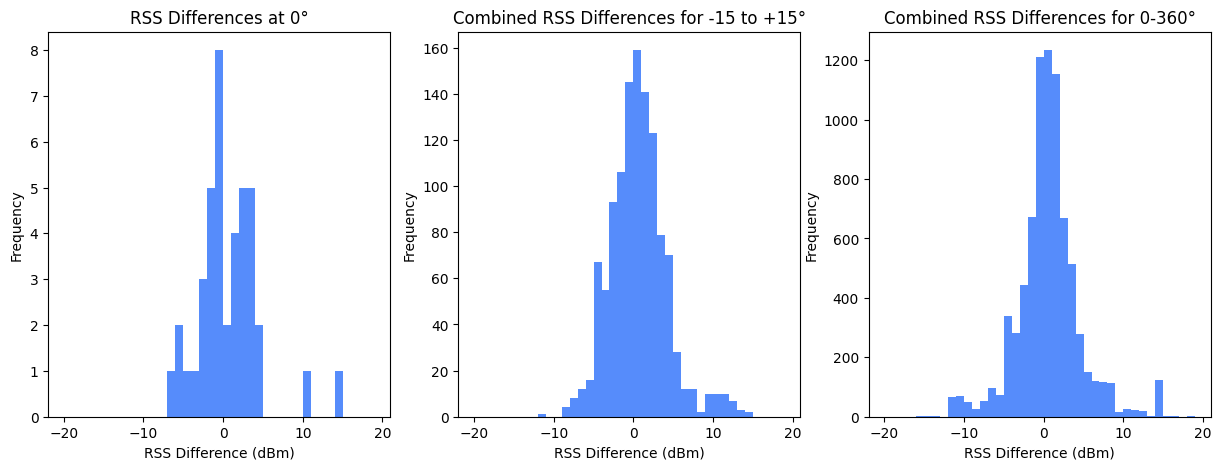

In [3]:
range_7_log = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, None)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("RSS Differences at 0°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.hist(rss_diff_at_gamma(range_7_log, 0), bins=np.arange(-20, 20))

plt.subplot(1, 3, 2)
diffs = []

for degree in range(-15, 15):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title(f"Combined RSS Differences for -15 to +15°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 3, 3)
diffs = []

for degree in range(0, 359):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title("Combined RSS Differences for 0-360°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.show()

## Examine All Range Trials Together

For all the range trials in `/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/`, examine the difference in RSS between two packets (sequential or with a large gap between them) for a given gamma. Collate this information into blocks of 30 degrees and then combine the data for all angles. The values of gamma for each packet are normalised so 0 degrees is pointing directly at the bee tag.

In [3]:
# parse all range trials into a dictionary
range_logs :dict[str, BleLog] = {}
range_trial_folder = "/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/"

range_logs["1.log"] = BleLogStatic(range_trial_folder + "1.log", tx_c, -1.449861, 53.368415, 128.1)
range_logs["2.log"] = BleLogStatic(range_trial_folder + "2.log", tx_c, -1.449851, 53.368798, 124.3)
range_logs["3.log"] = BleLogStatic(range_trial_folder + "3.log", tx_c, -1.449712, 53.369261, 111.0)
range_logs["4.log"] = BleLogStatic(range_trial_folder + "4.log", tx_c, -1.449732, 53.369659, 123.5)
range_logs["5.log"] = BleLogStatic(range_trial_folder + "5.log", tx_c, -1.449705, 53.369932, 112.0)
range_logs["6.log"] = BleLogStatic(range_trial_folder + "6.log", tx_c, -1.449617, 53.370239, 111.2)
range_logs["7.log"] = BleLogStatic(range_trial_folder + "7.log", tx_c, -1.449647, 53.370649, 106.6)
range_logs["8.log"] = BleLogStatic(range_trial_folder + "8.log", tx_c, -1.449575, 53.371191, 104.9)
range_logs["9.log"] = BleLogStatic(range_trial_folder + "9.log", tx_c, -1.449595, 53.371545, 107.7)

BleLog | tx: c, no.packets: 8314, time: 86.369s
BleLogStatic | angle offset: -74.055
BleLog | tx: c, no.packets: 3108, time: 75.356s
BleLogStatic | angle offset: -23.199
BleLog | tx: c, no.packets: 3208, time: 89.925s
BleLogStatic | angle offset: -16.699
BleLog | tx: c, no.packets: 6502, time: 87.054s
BleLogStatic | angle offset: -10.929
BleLog | tx: c, no.packets: 1518, time: 91.795s
BleLogStatic | angle offset: -9.728
BleLog | tx: c, no.packets: 93, time: 71.421s
BleLogStatic | angle offset: -9.507
BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLogStatic | angle offset: -7.374
BleLog | tx: c, no.packets: 1536, time: 96.692s
BleLogStatic | angle offset: -6.699
BleLog | tx: c, no.packets: 2864, time: 73.173s
BleLogStatic | angle offset: -5.807


In [4]:
for fName, bleLogStatic in range_logs.items():
    print(f"{fName} distance: {bleLogStatic.dist_to_transmitter()}m")

1.log distance: 21.840329667841555m
2.log distance: 53.31041174104736m
3.log distance: 104.4030650891055m
4.log distance: 147.6787053031005m
5.log distance: 177.55280904564702m
6.log distance: 211.91035840656775m
7.log distance: 257.12642804659345m
8.log distance: 317.1655719021218m
9.log distance: 355.8258000763857m


### Sequential Packet Differences

The difference is taken between the current packet and the packet at the same gamma in the next transmitter rotation (approximately 2 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

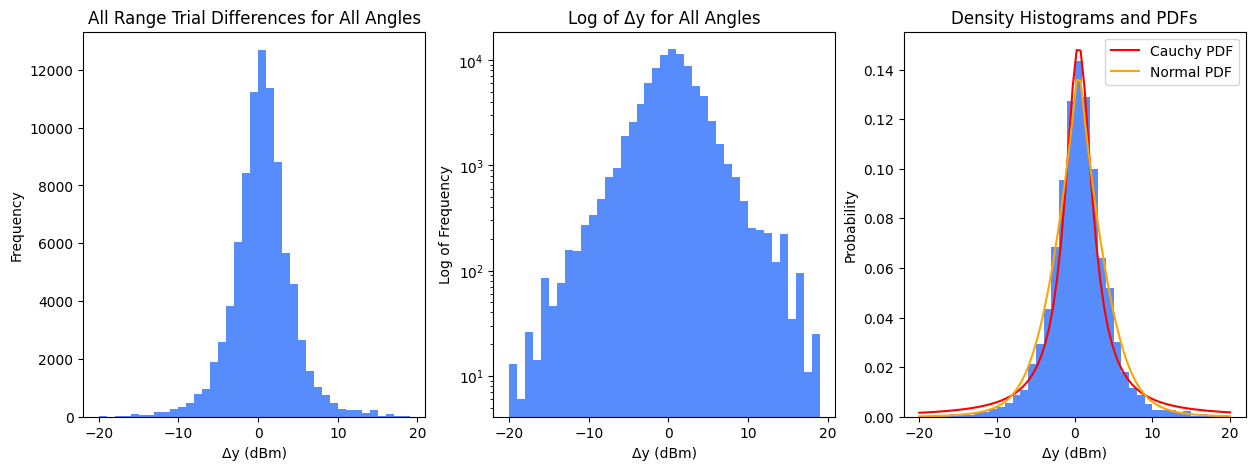

In [5]:
diffs_1 = combined_rss_at_gamma_analysis(range_logs, 1)
x_axis = np.linspace(-20, 20, 1000)

plt.show()

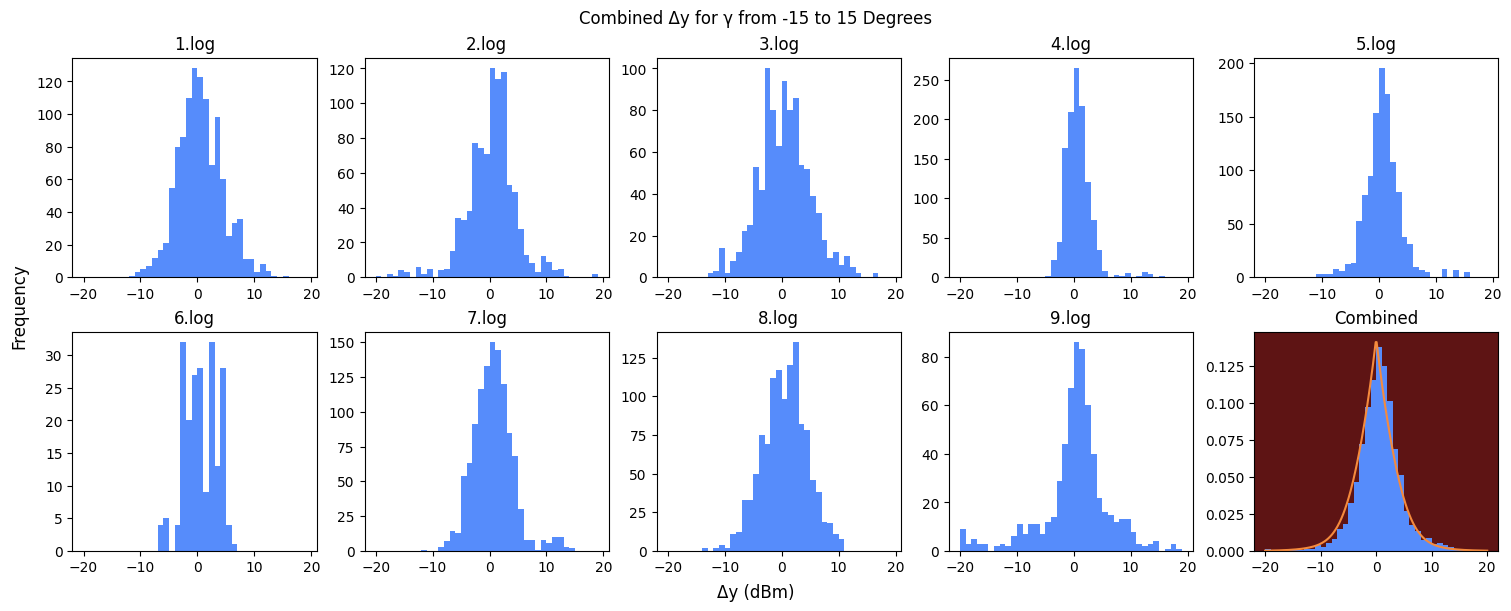

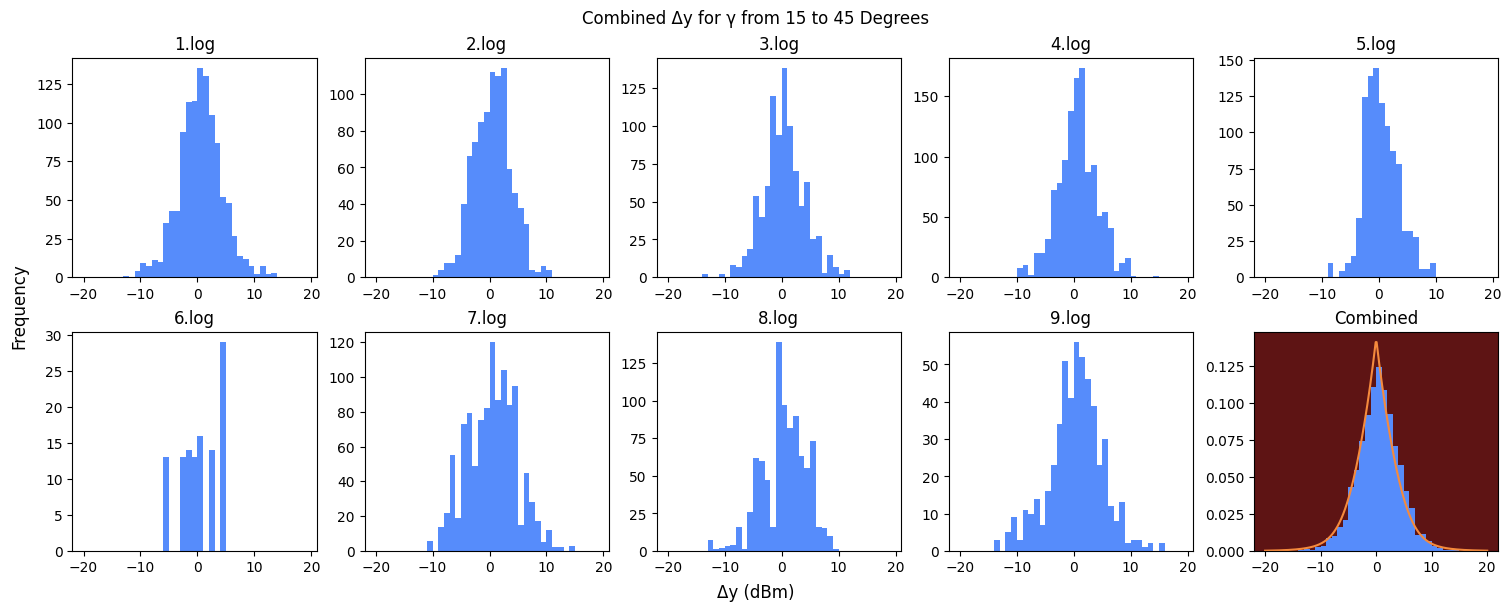

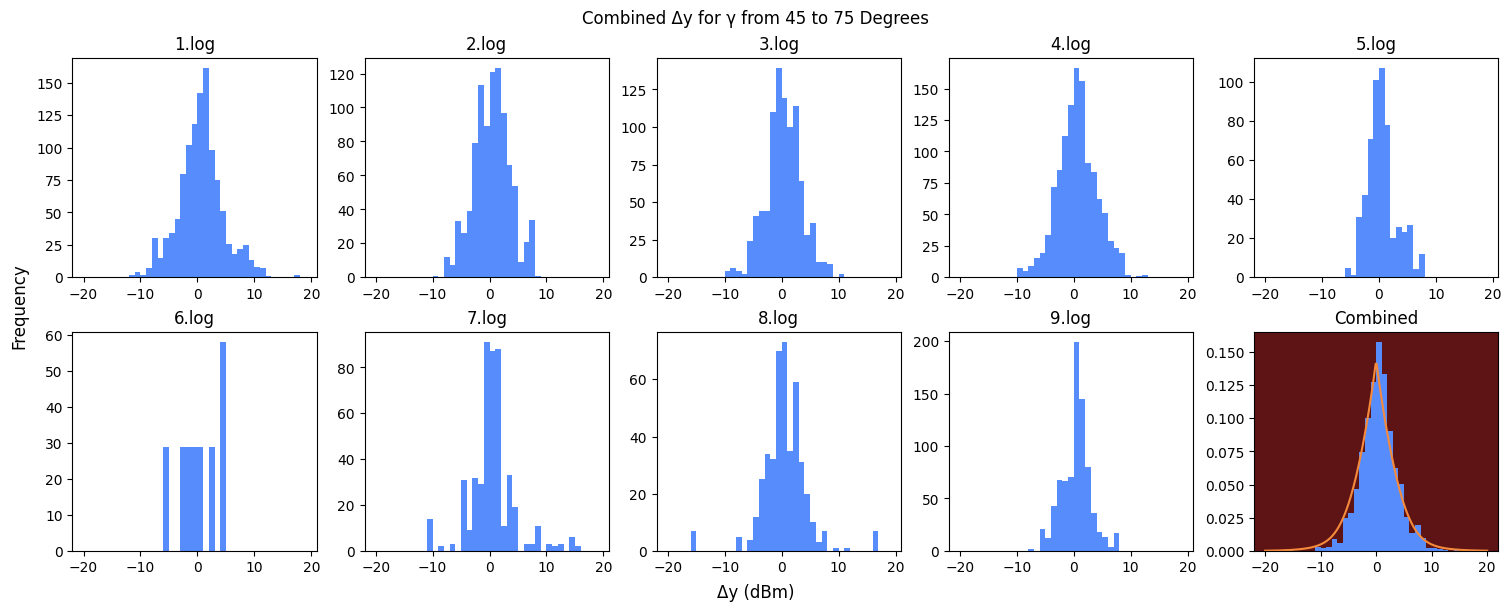

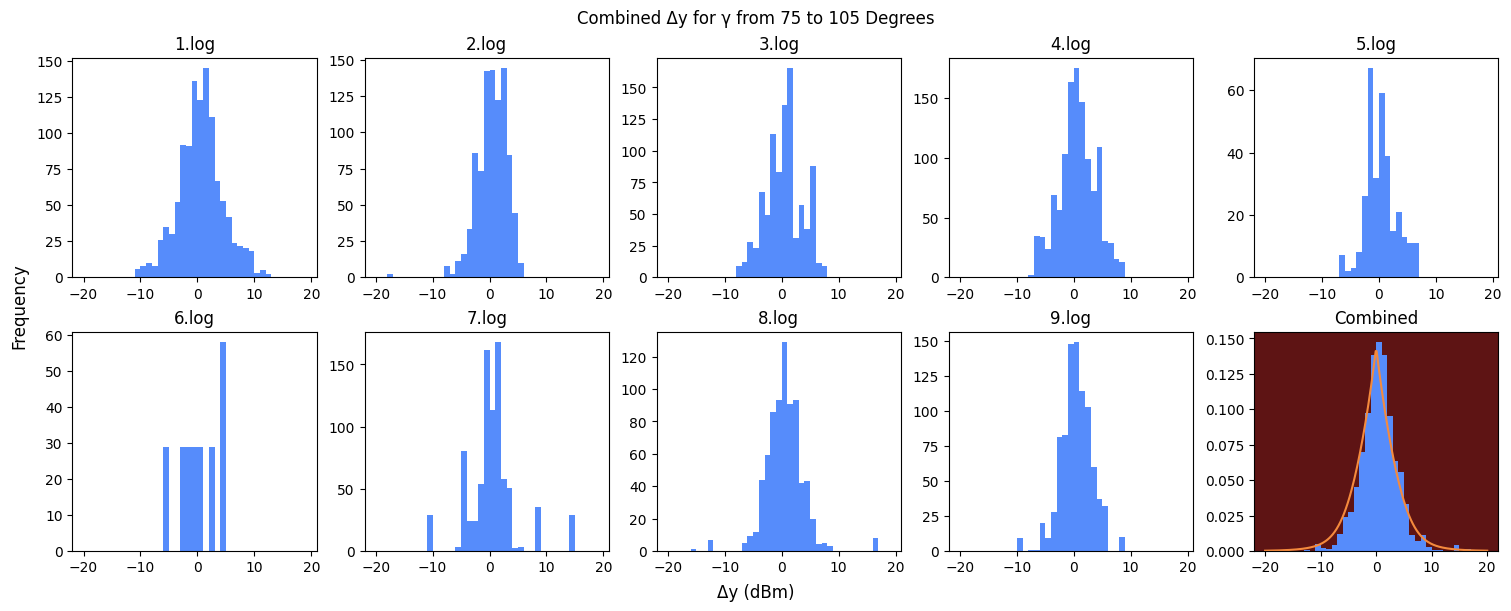

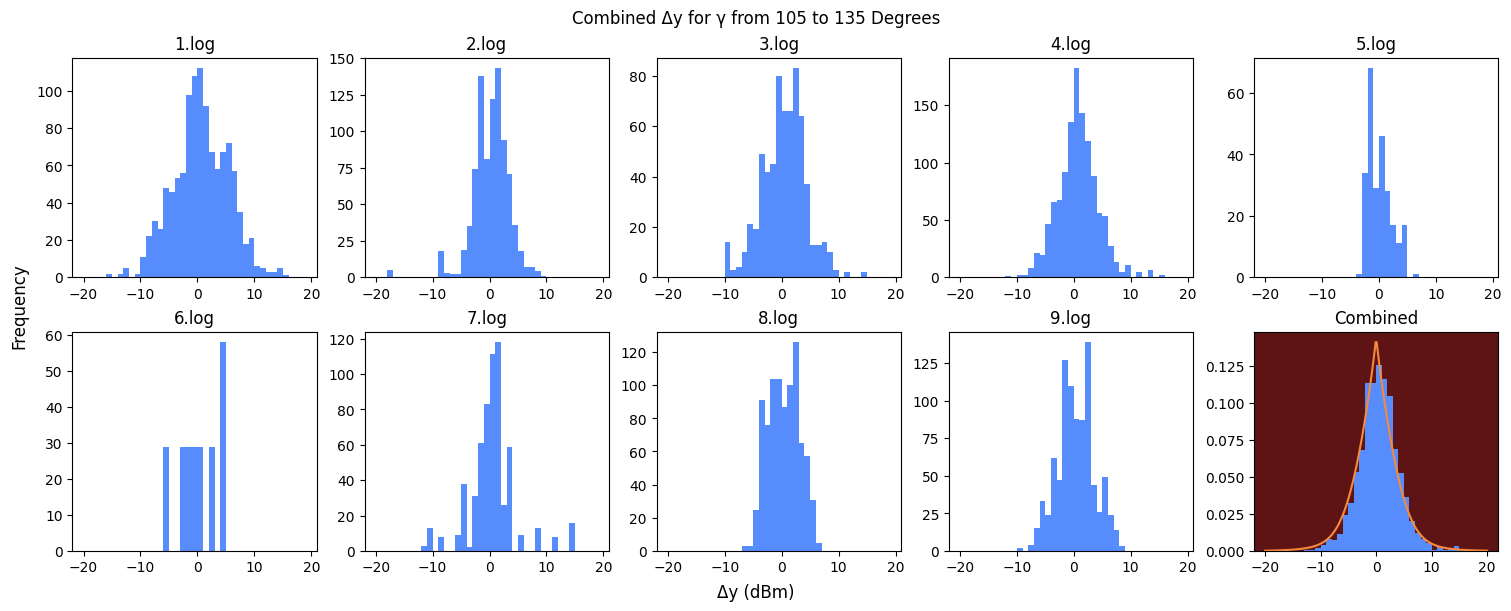

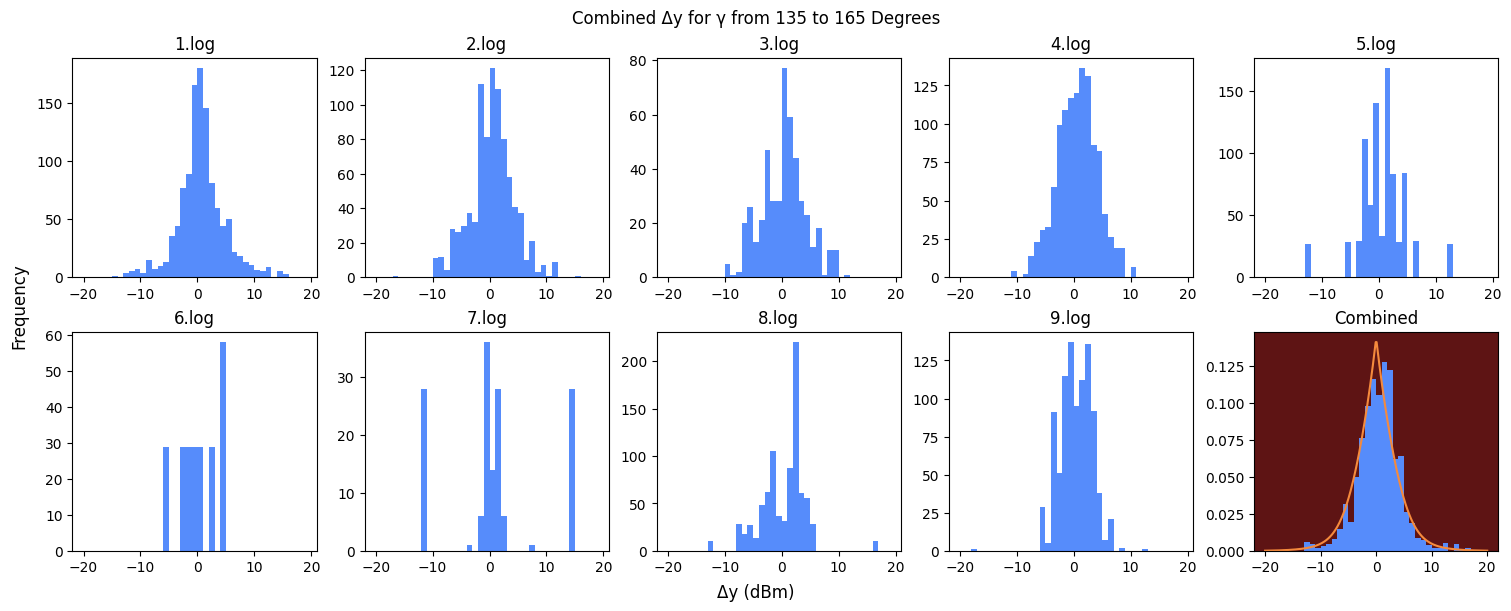

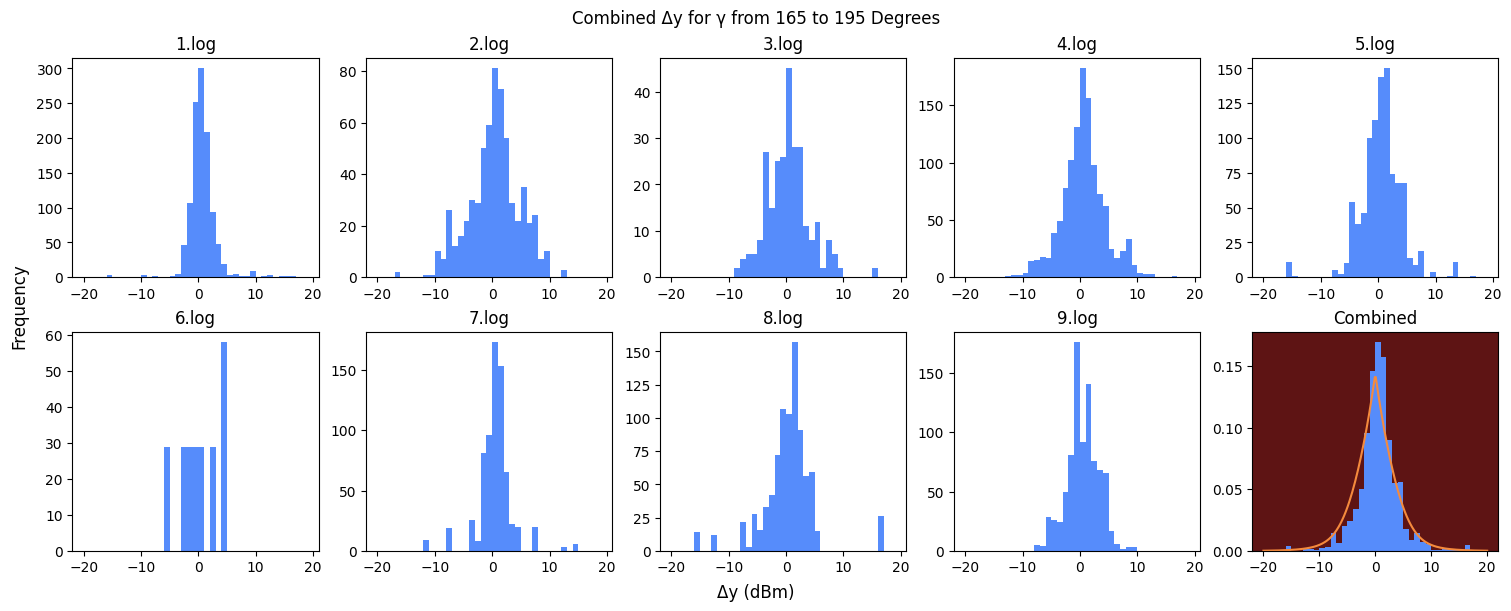

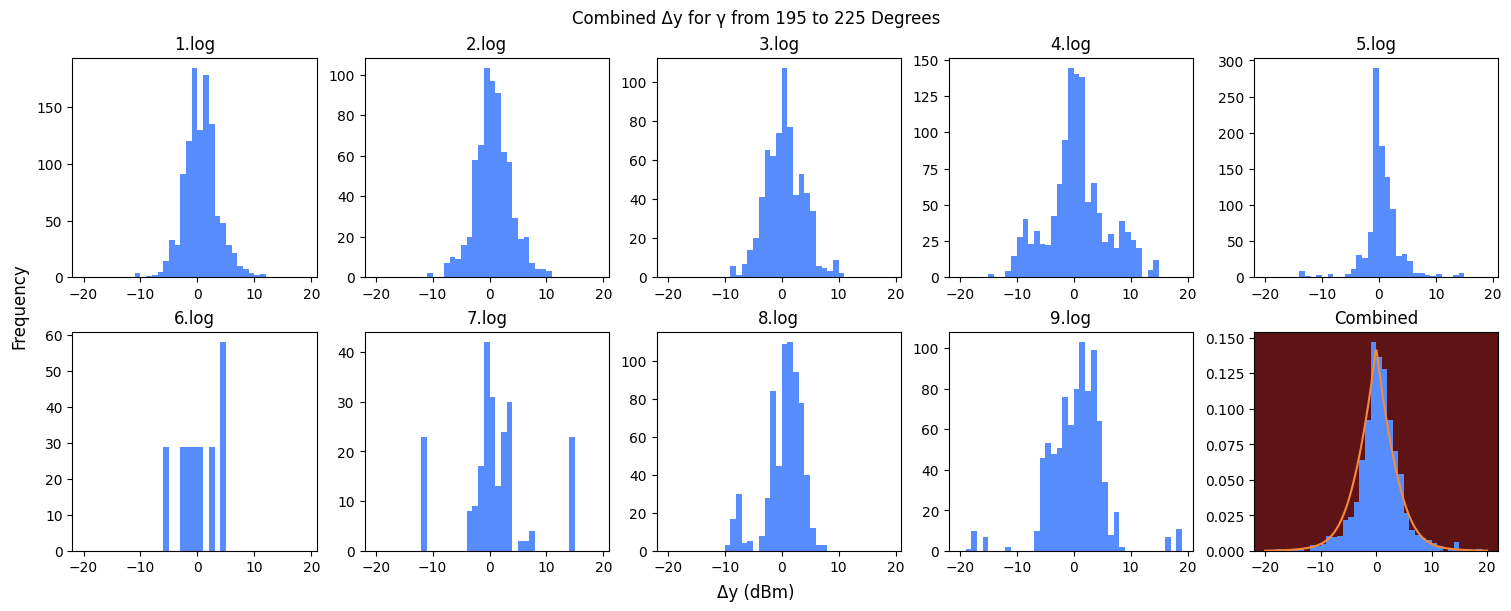

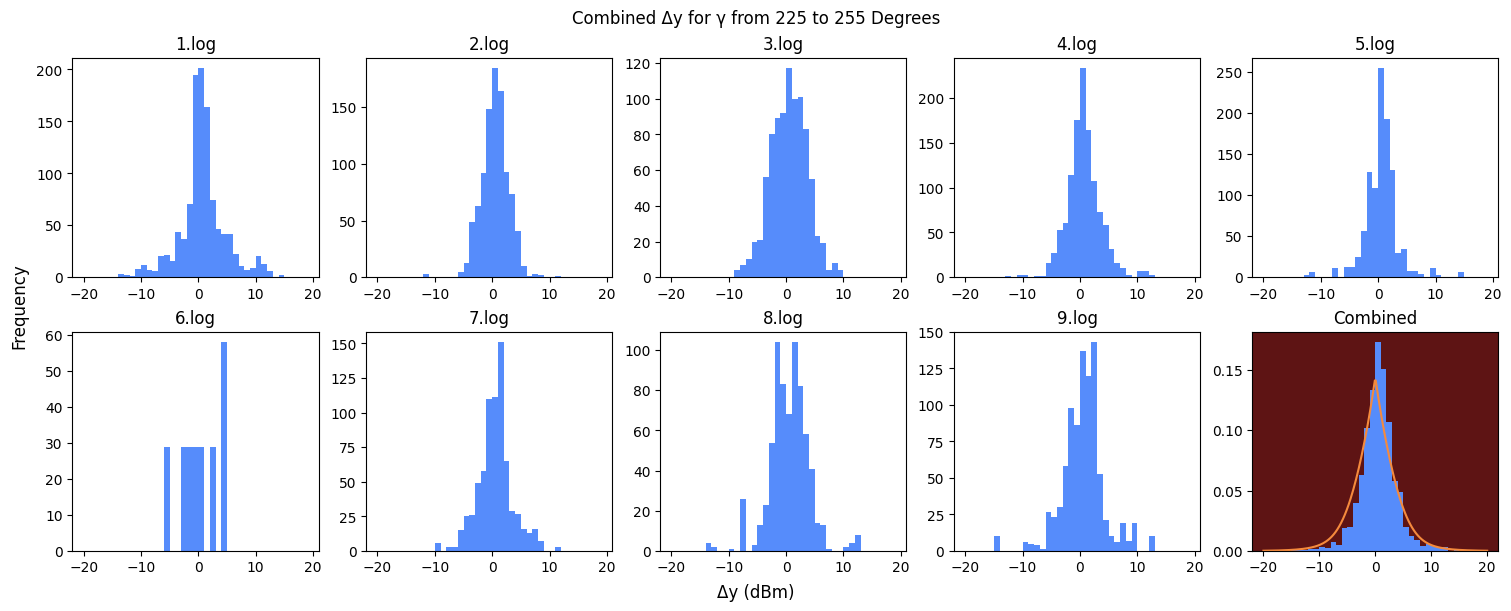

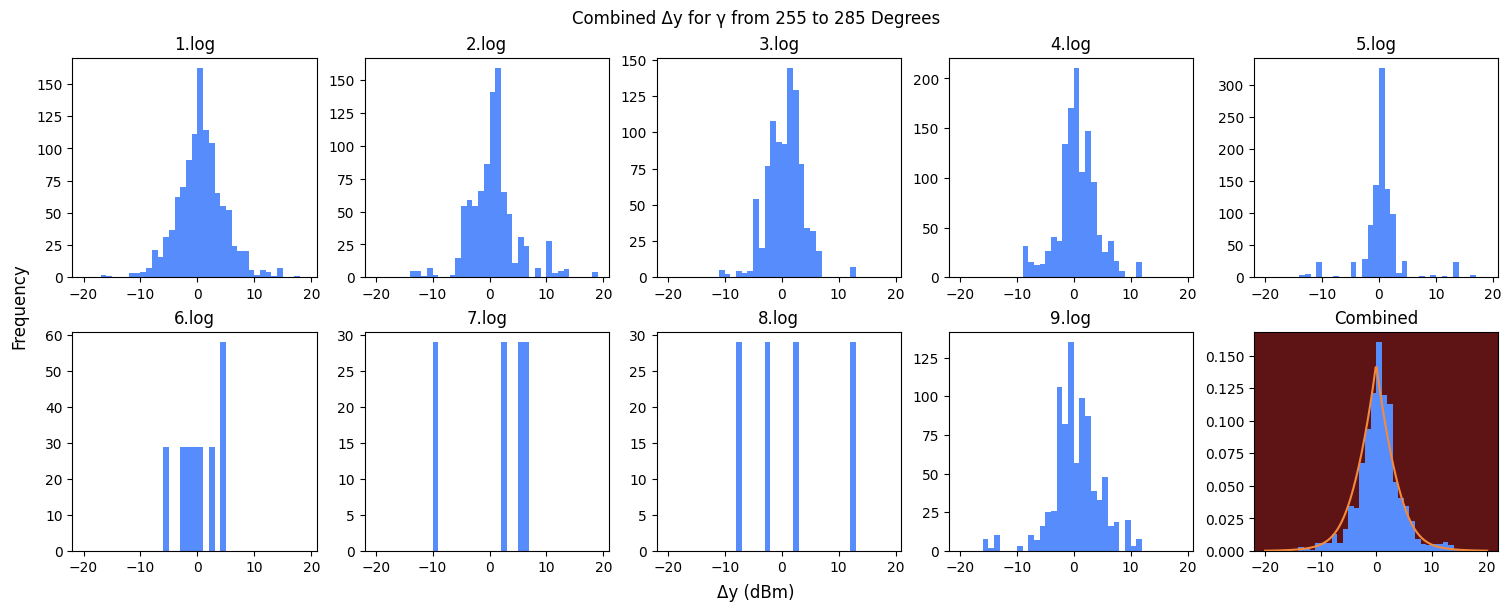

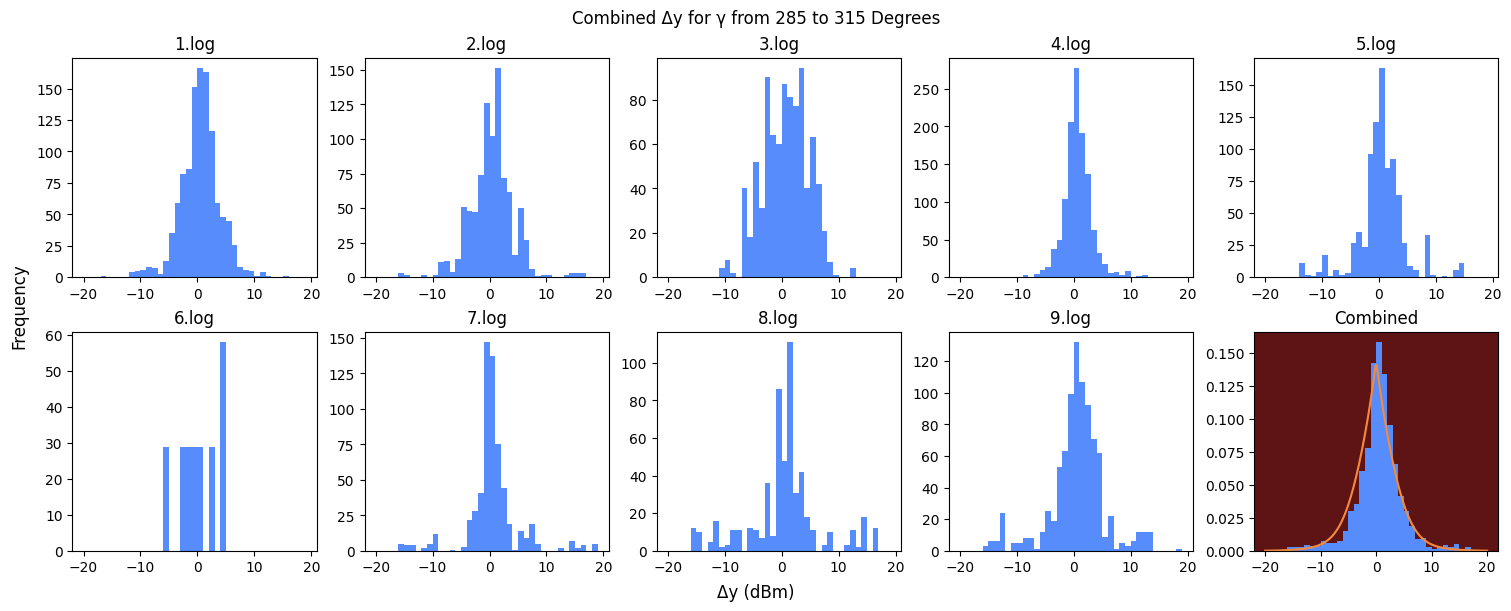

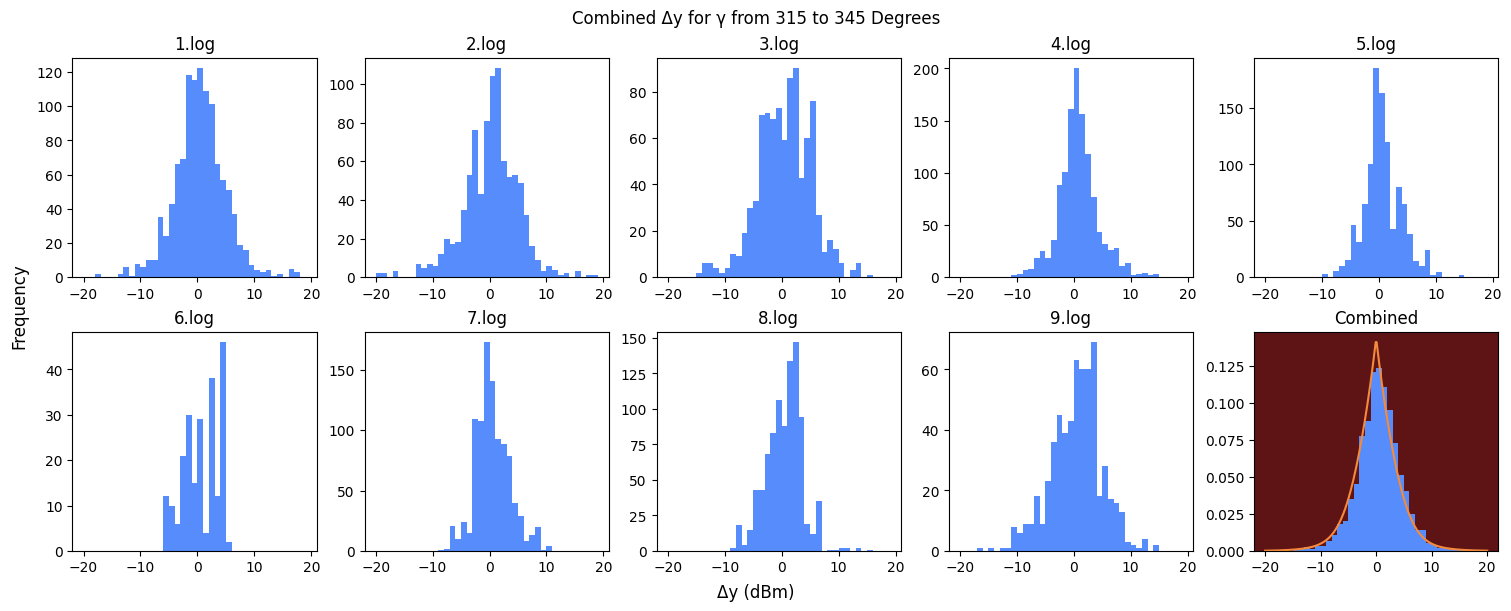

In [6]:
range_trial_rss_diffs_in_blocks(range_logs)

### Two Packet Differences

This would be applicable if a sample is taken over 4 seconds

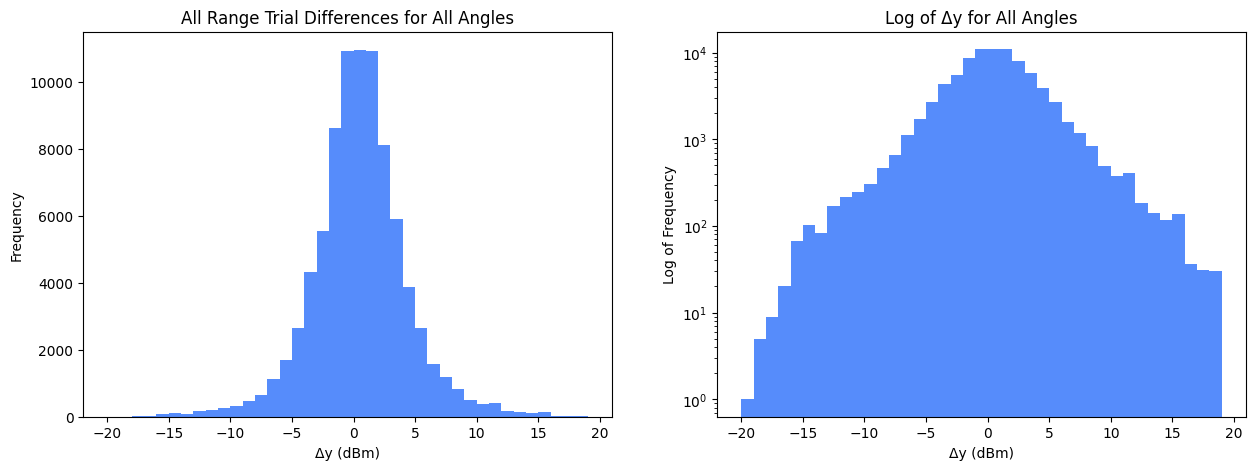

In [7]:
diffs_2 = combined_rss_at_gamma_analysis(range_logs, 2, False)

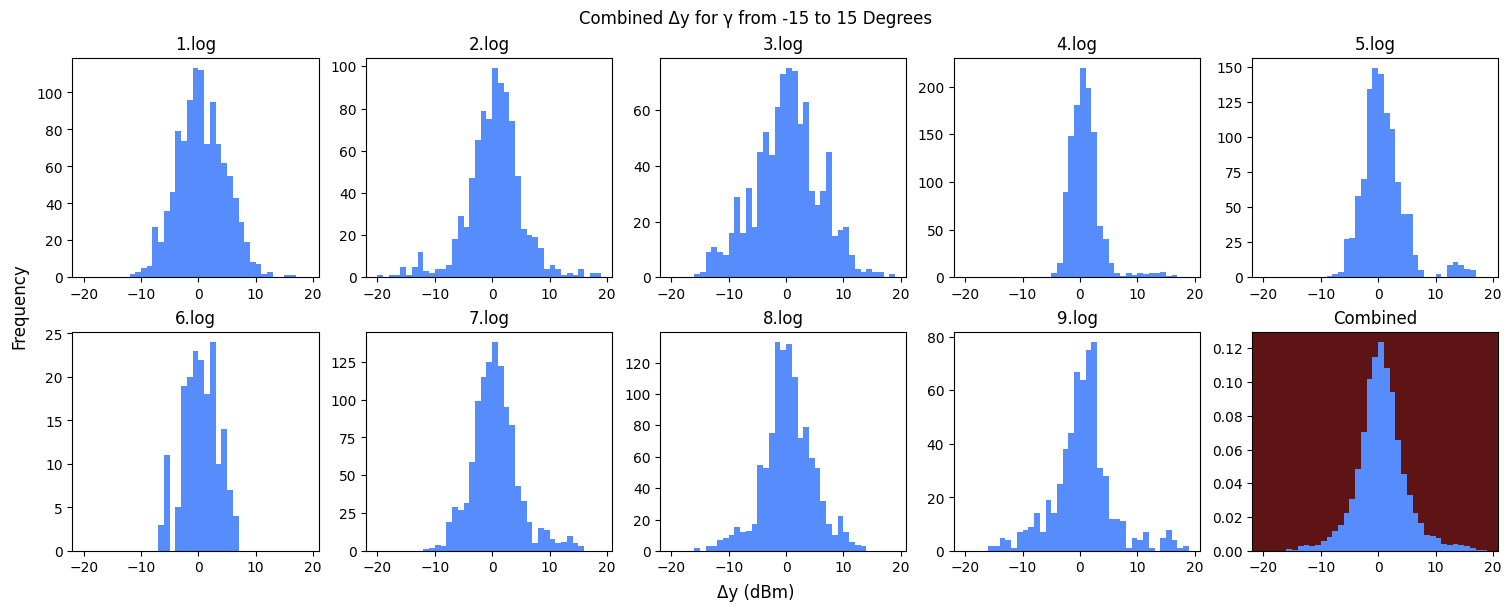

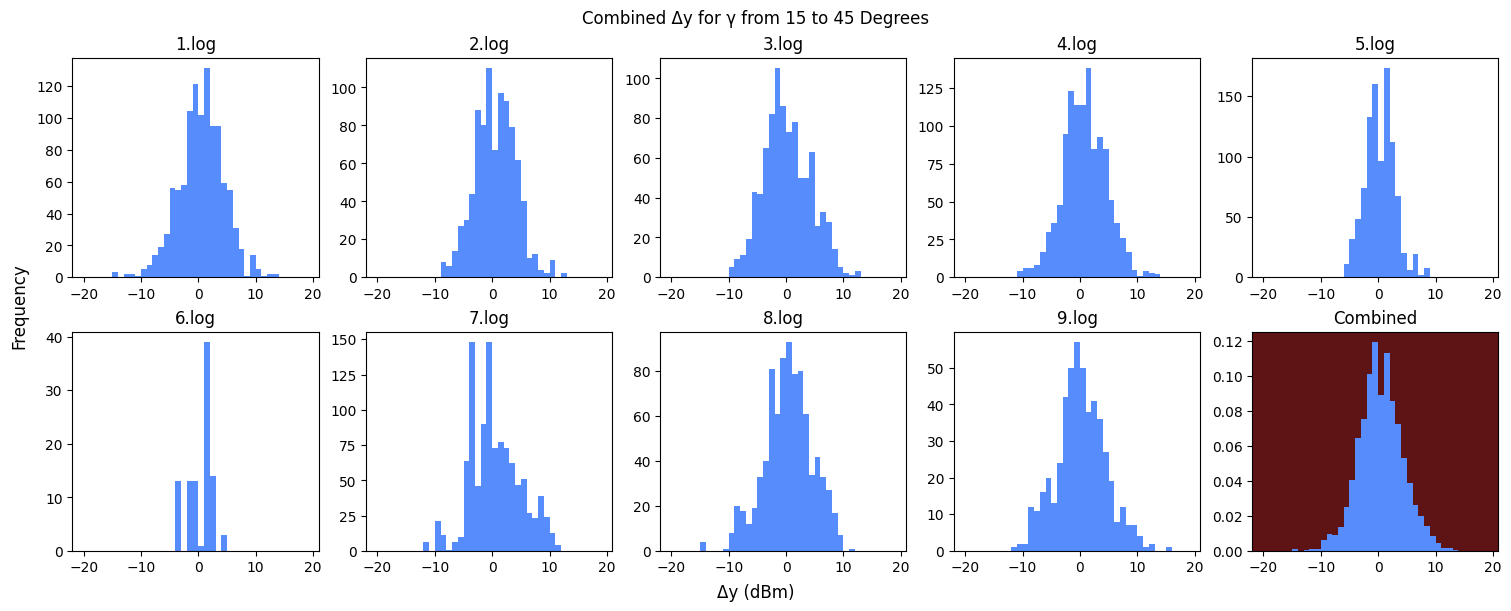

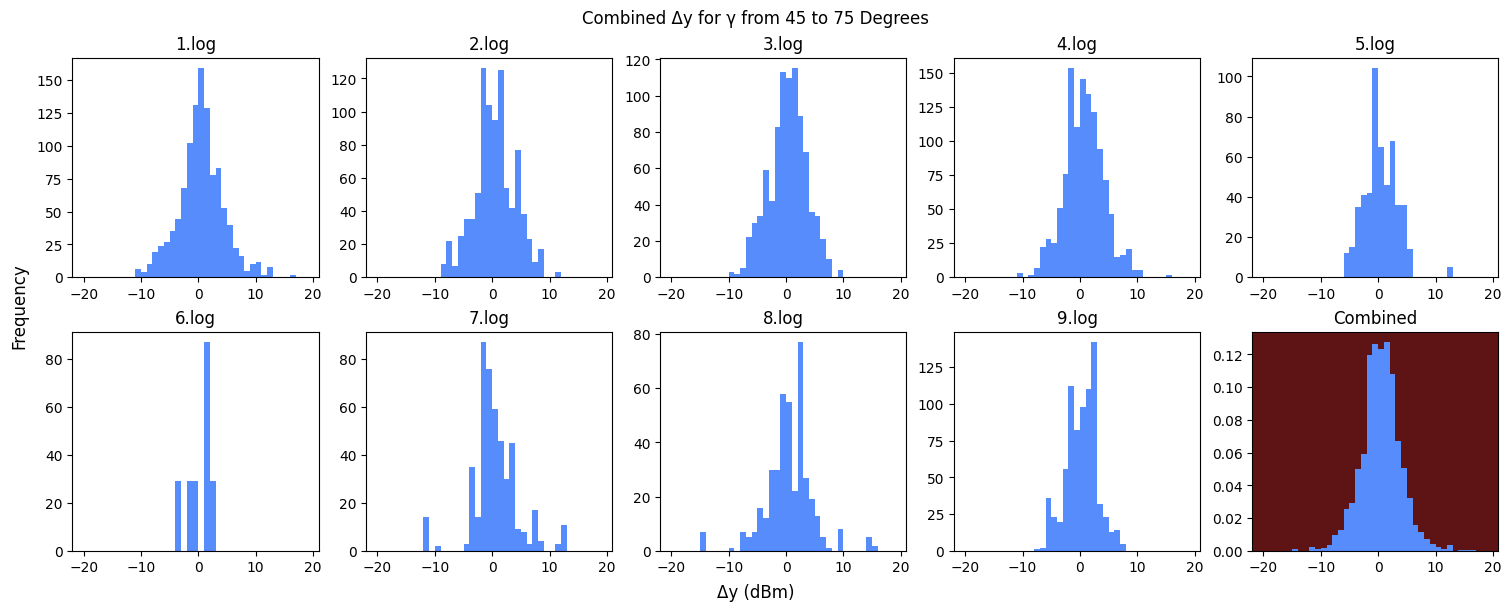

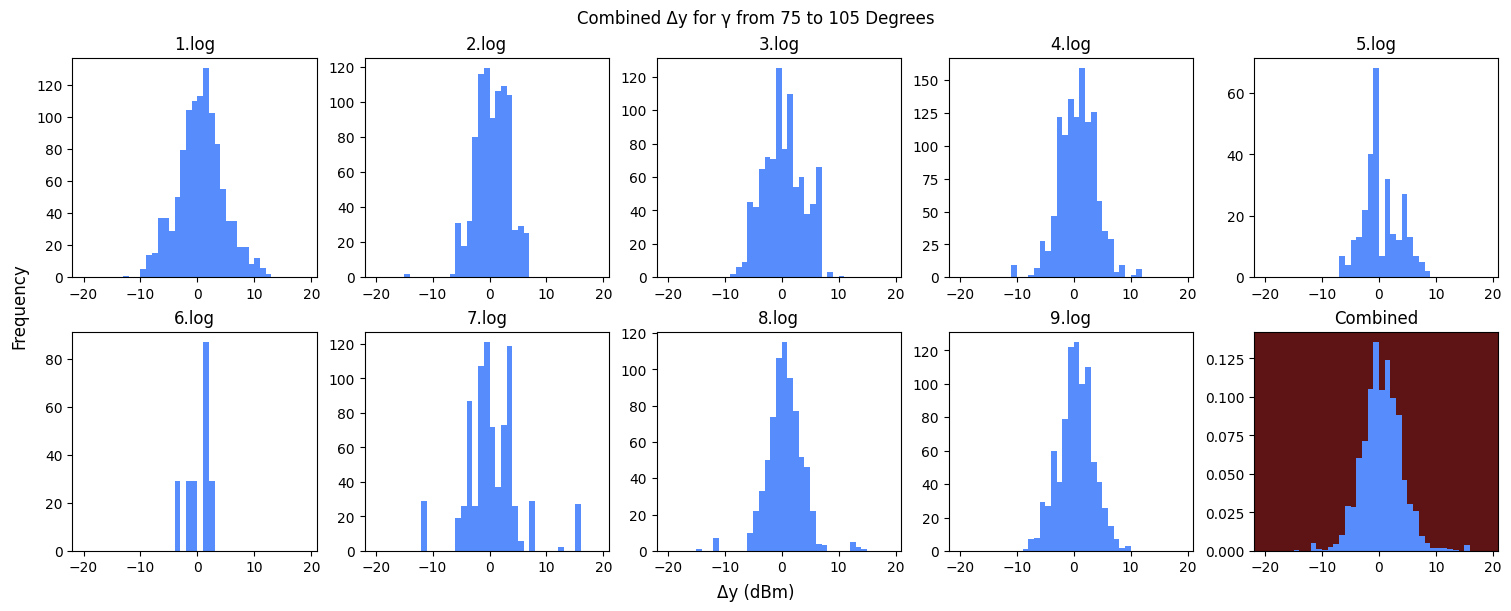

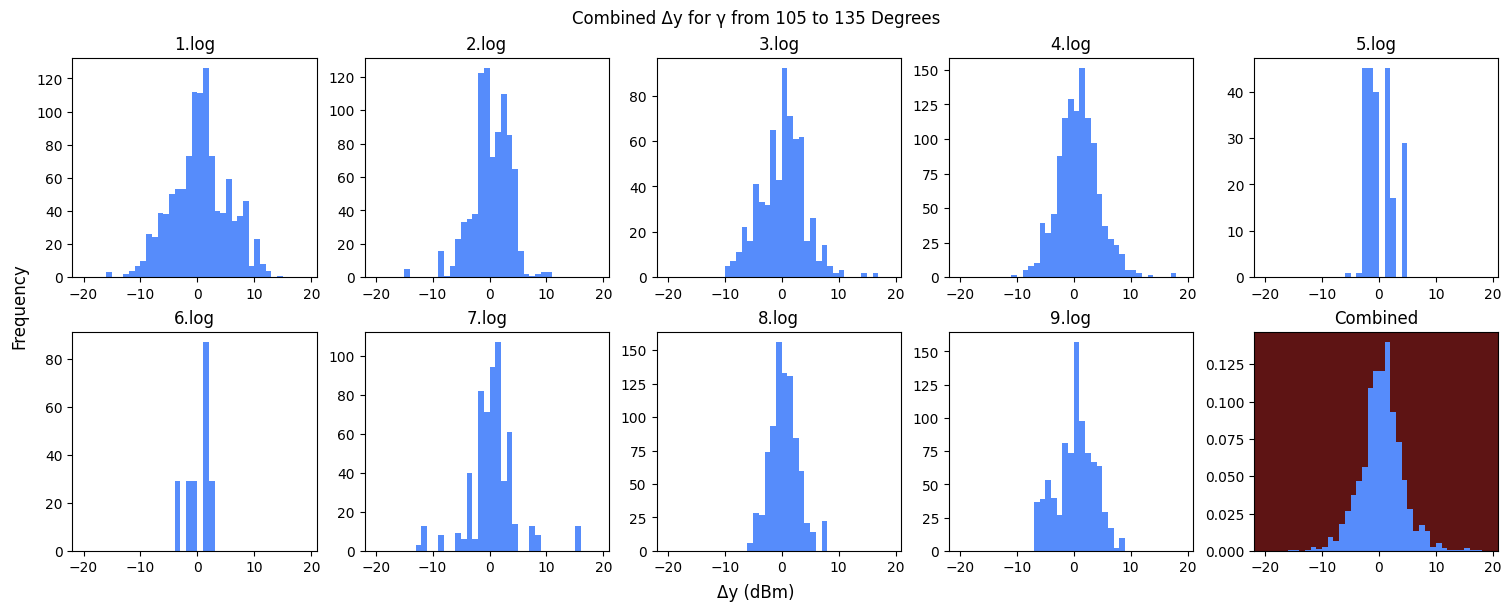

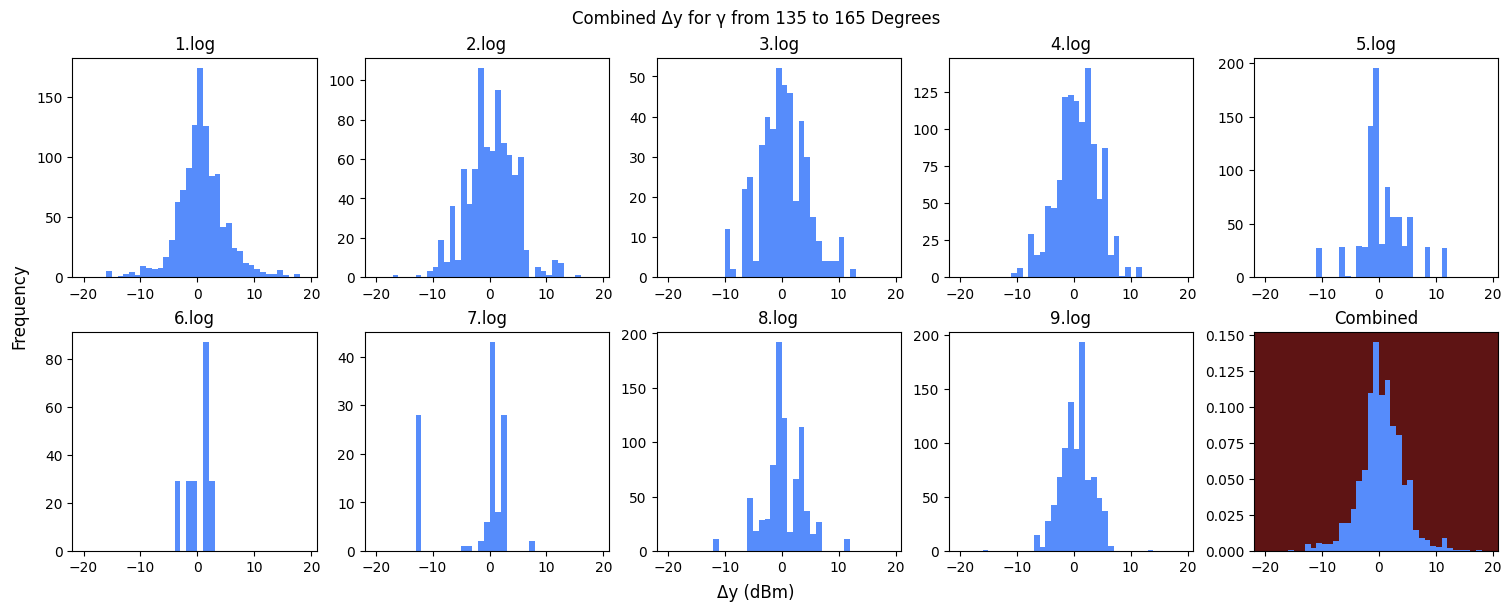

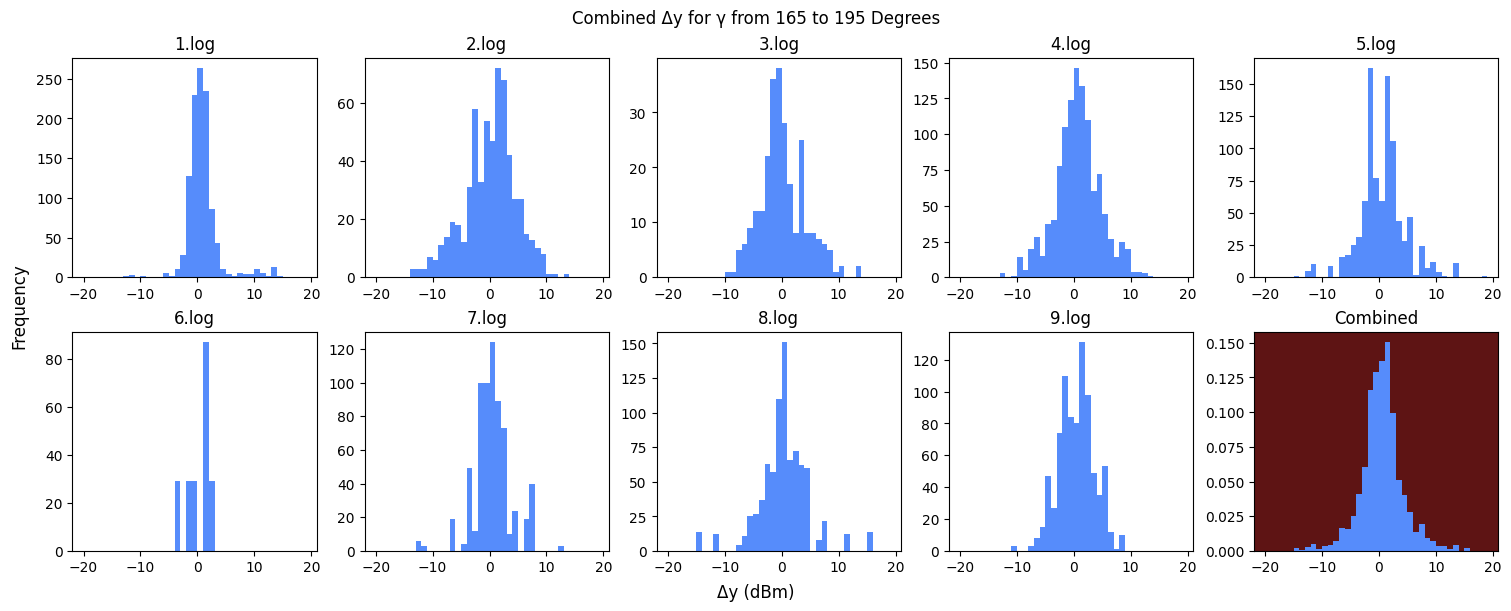

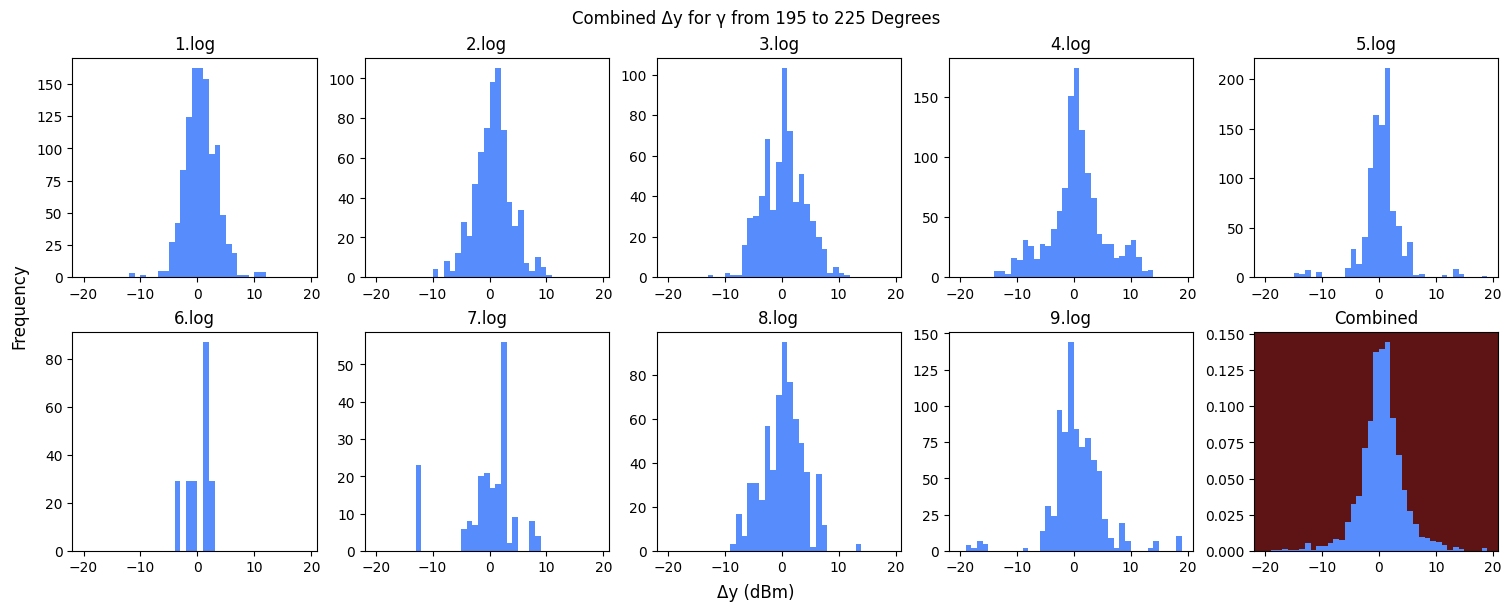

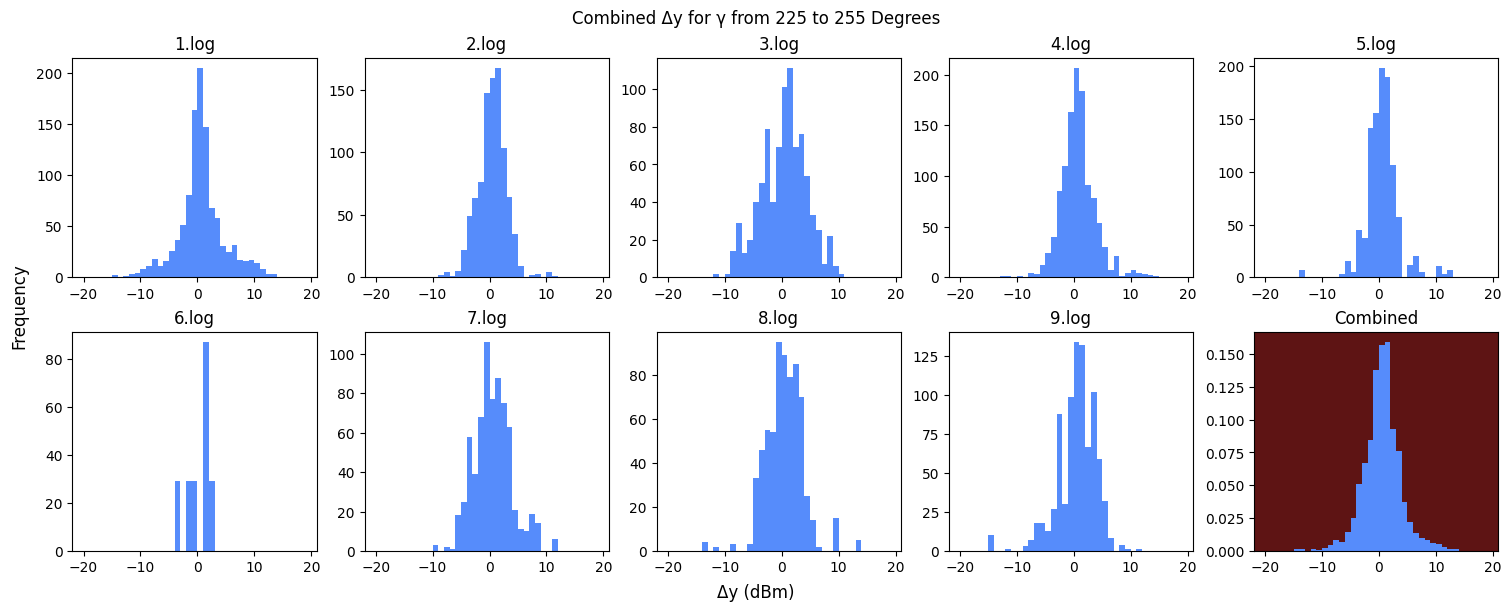

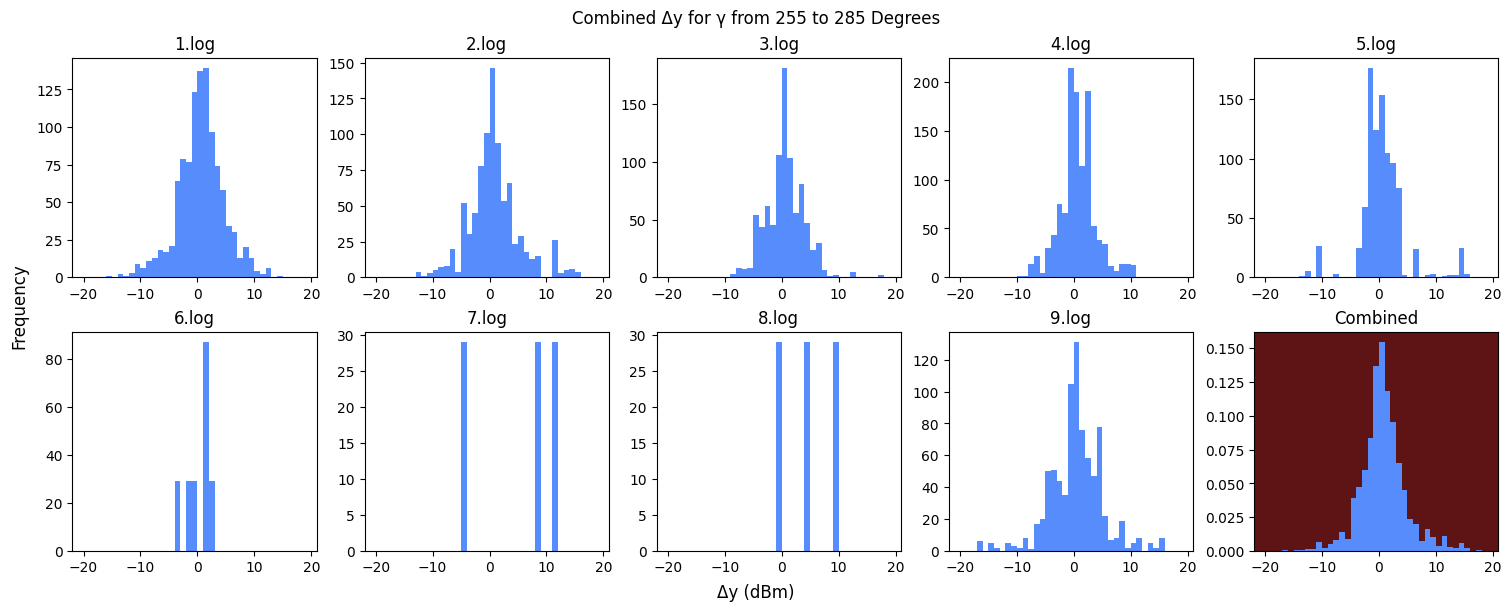

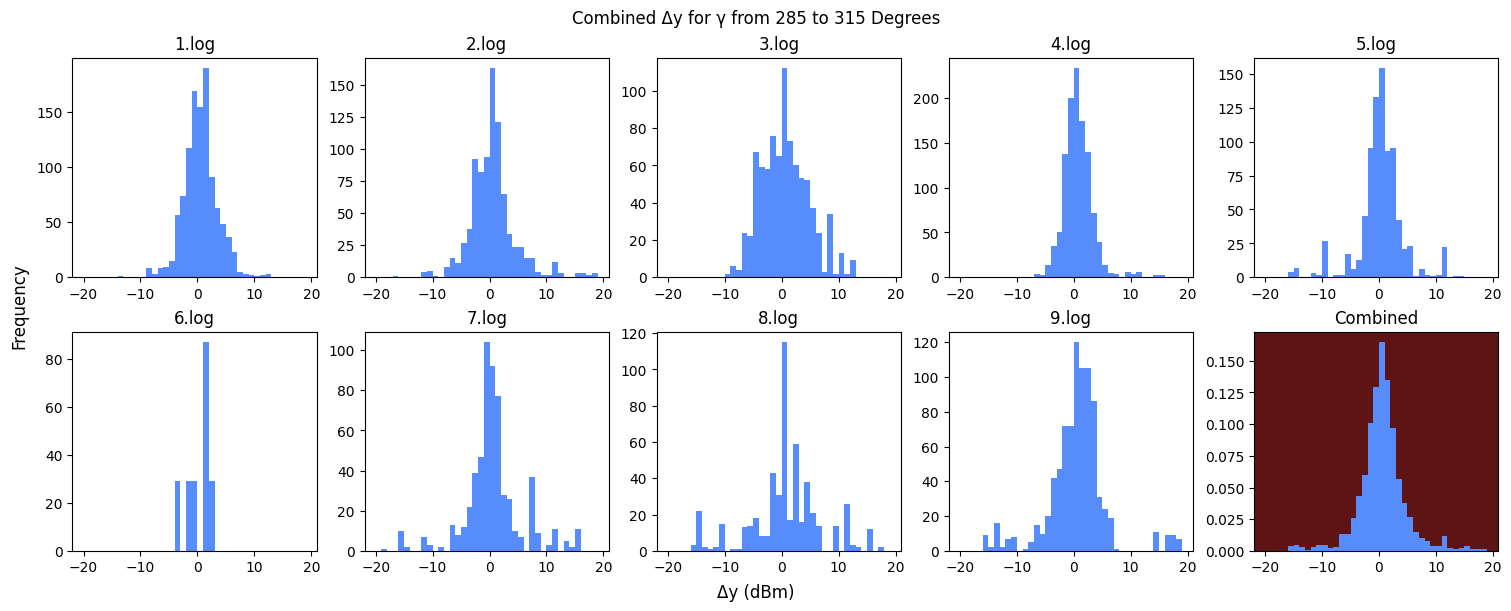

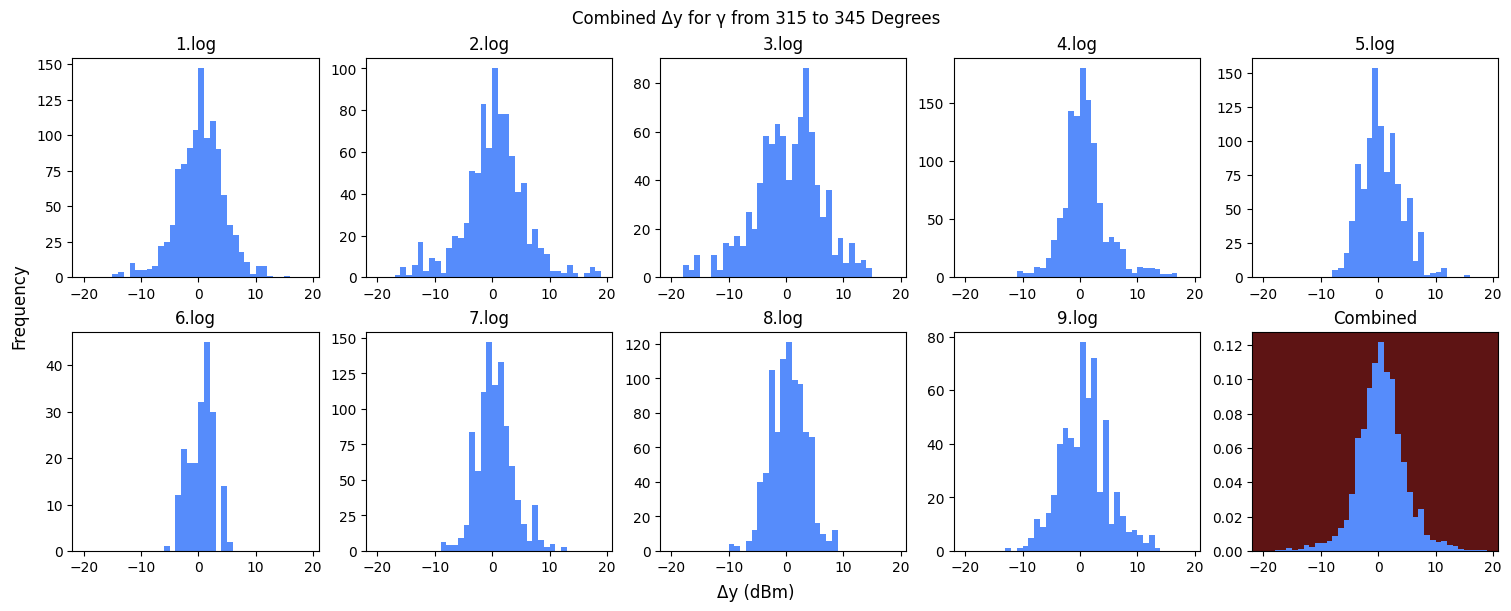

In [4]:
range_trial_rss_diffs_in_blocks(range_logs, 2, False)

### Five Packet Differences

The difference is taken between the current packet and the packet at the same gamma in five transmitter-rotations' time (approximately 10 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

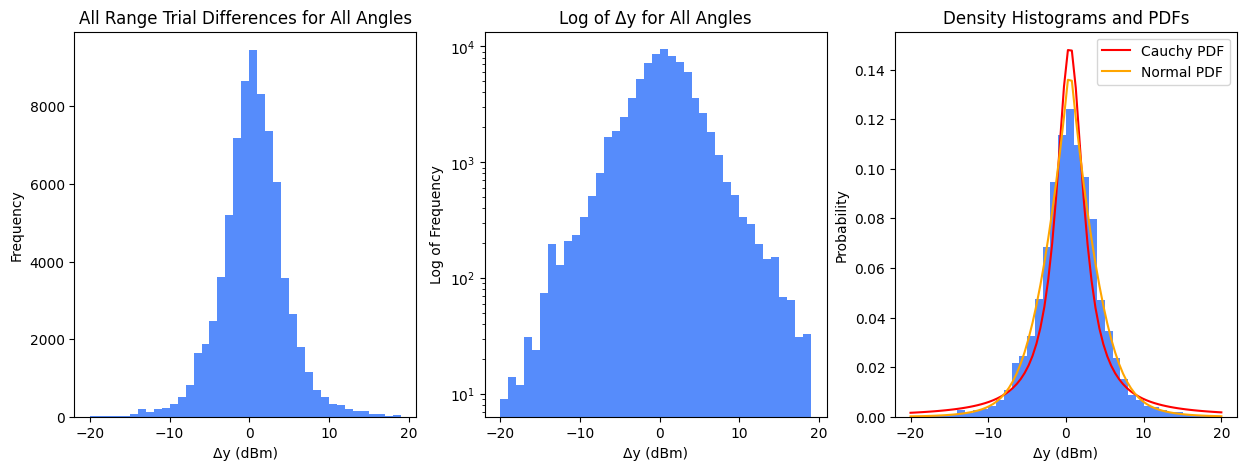

In [9]:
diffs_5 = combined_rss_at_gamma_analysis(range_logs, 5)

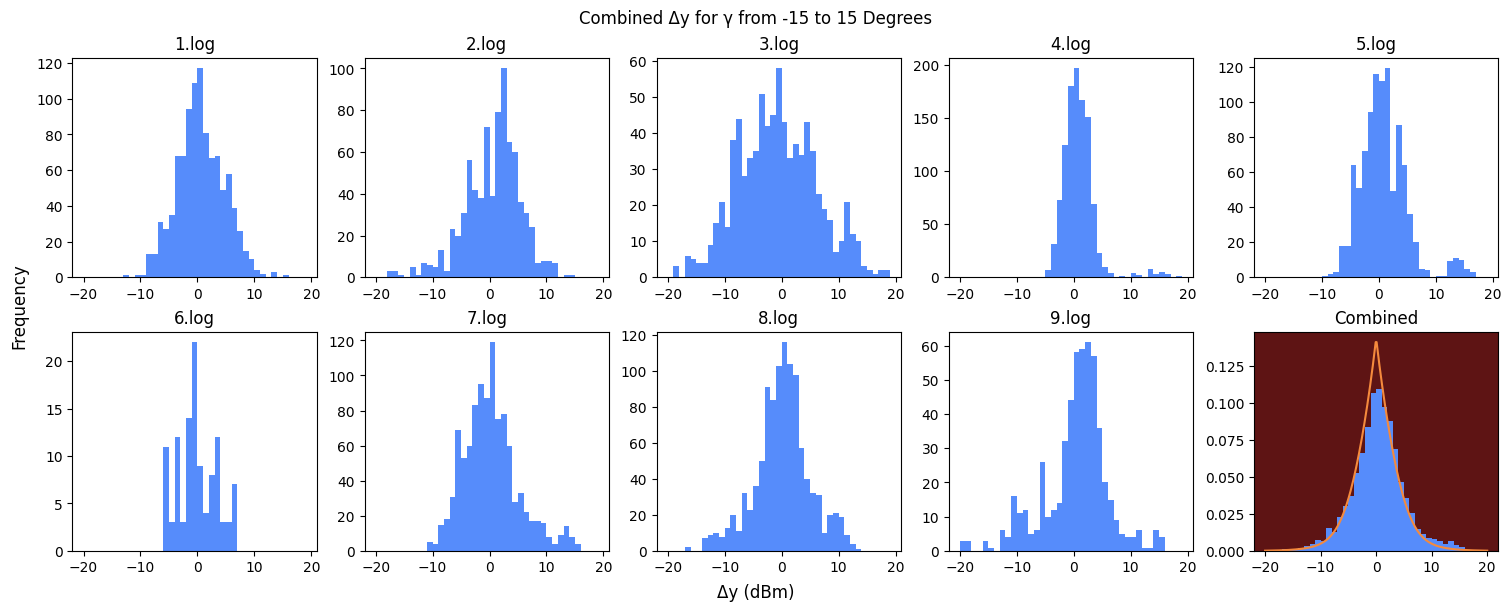

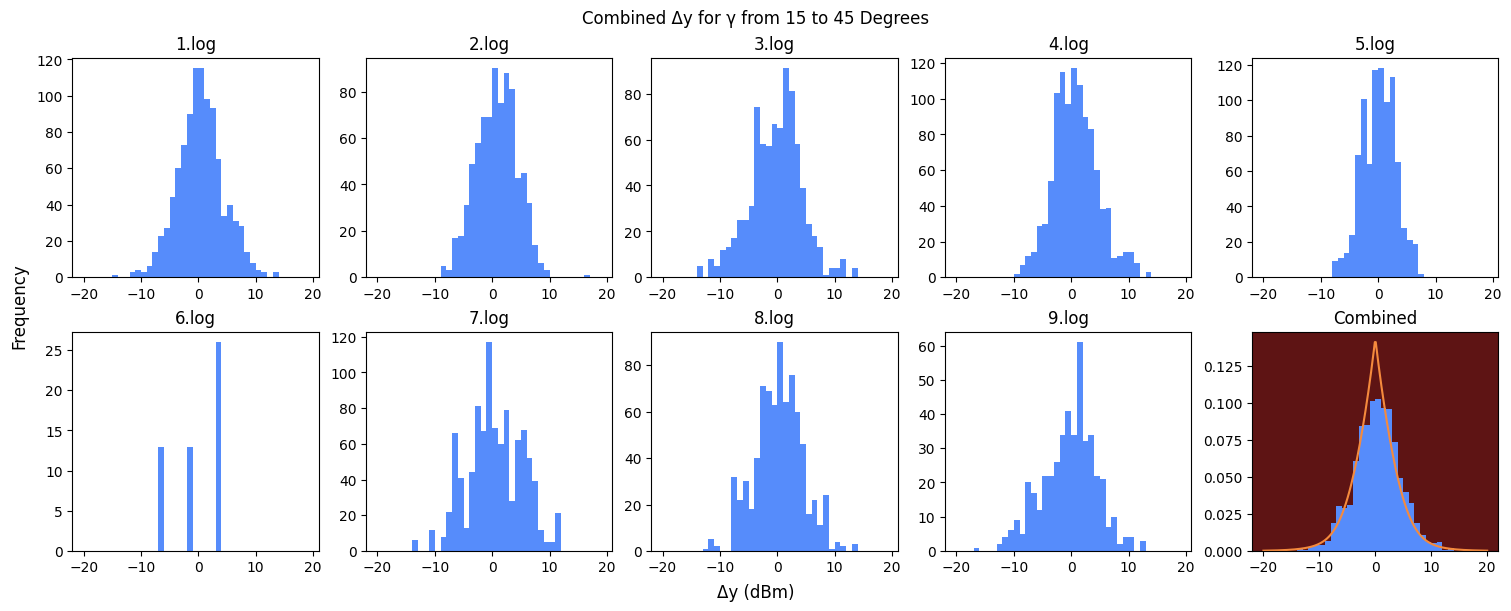

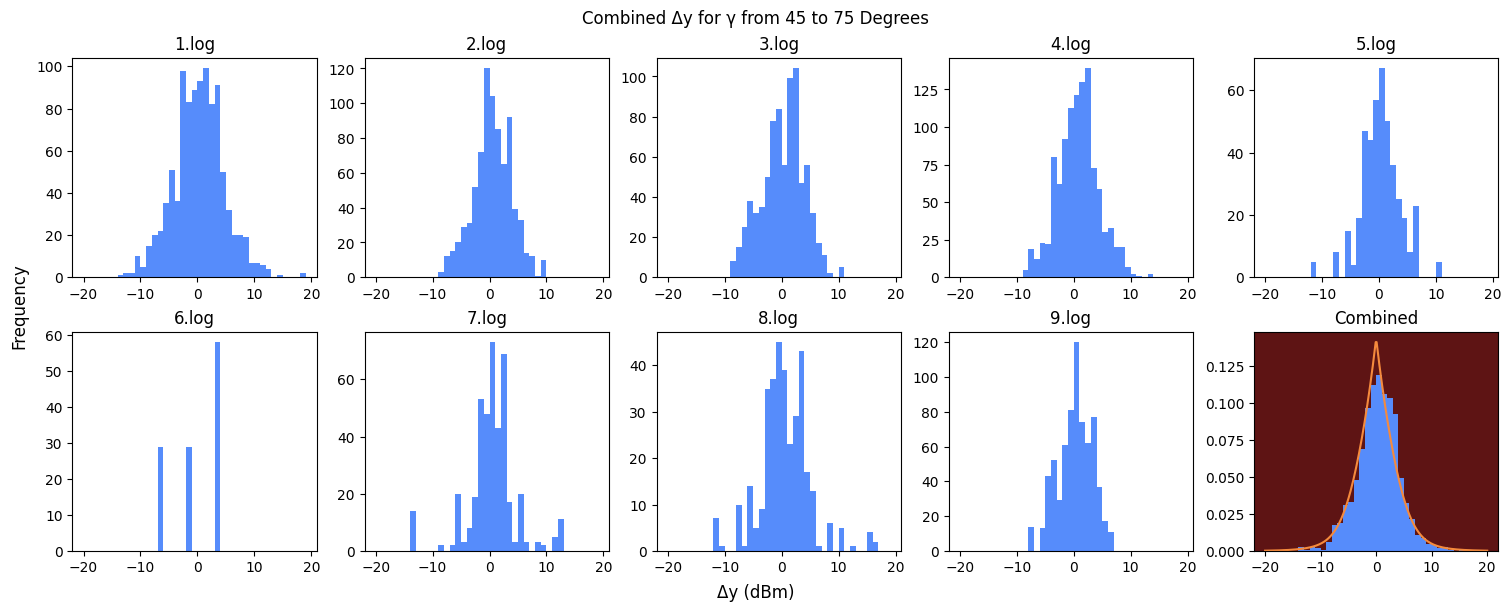

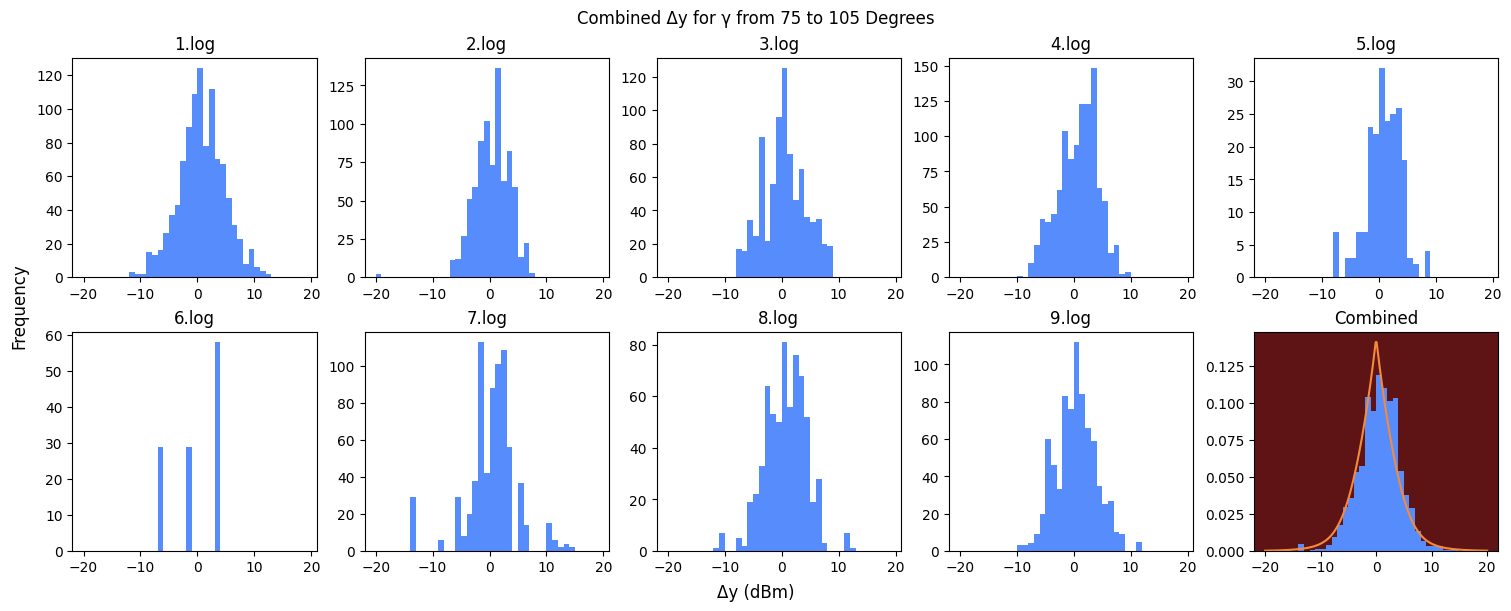

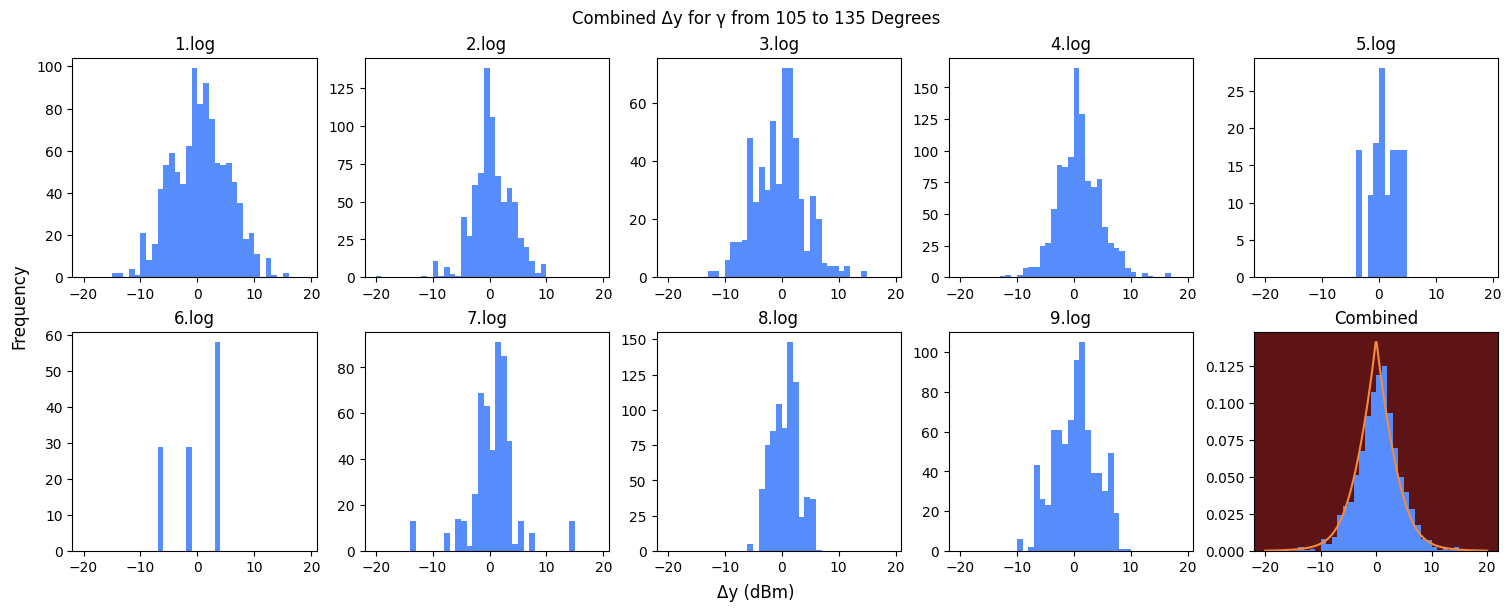

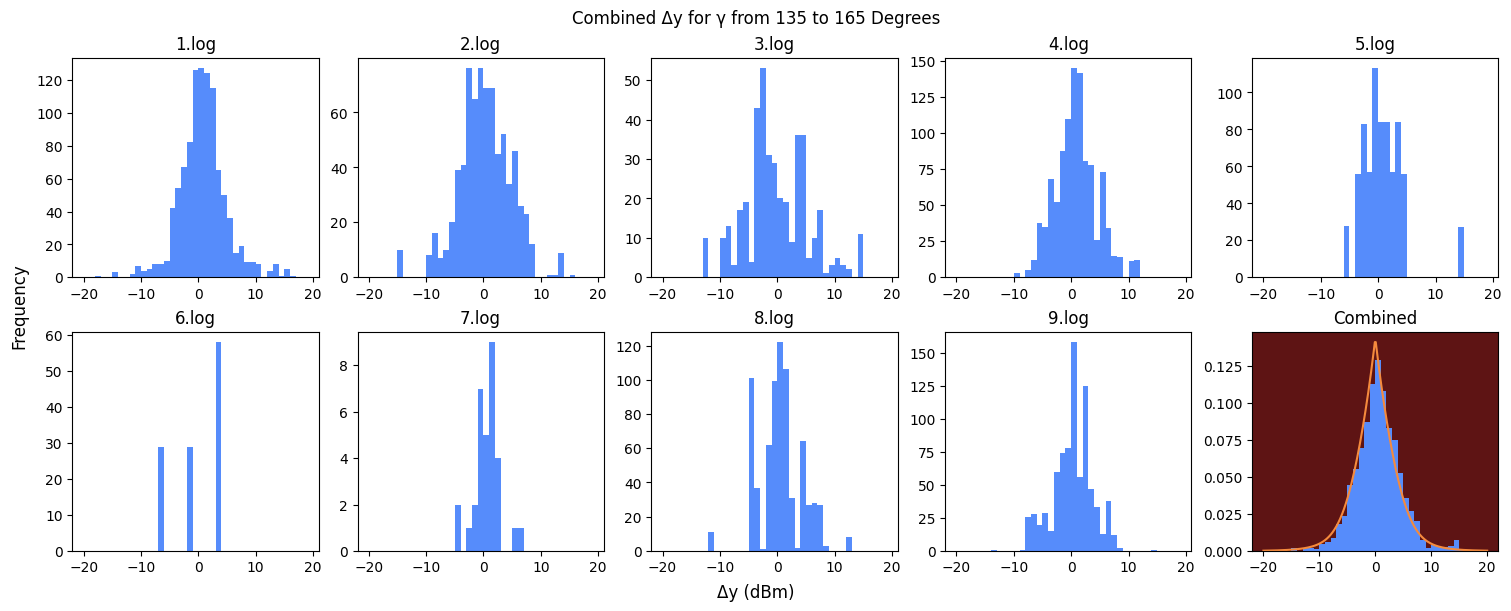

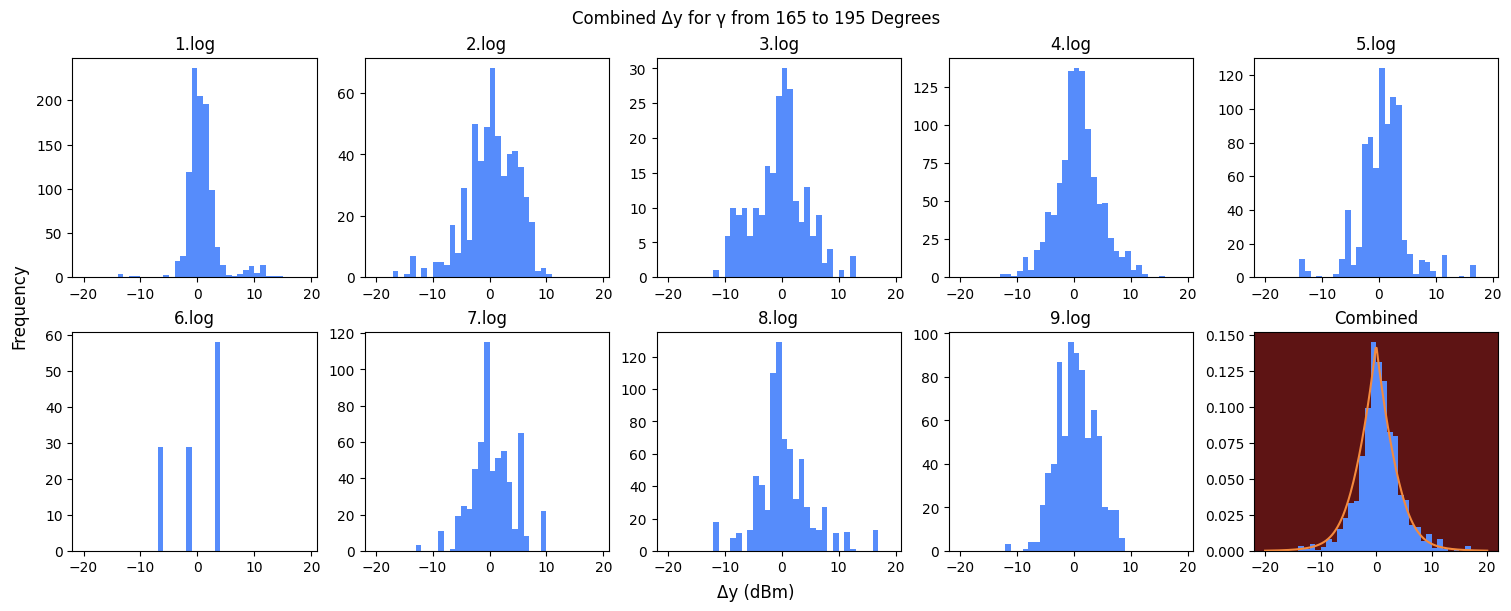

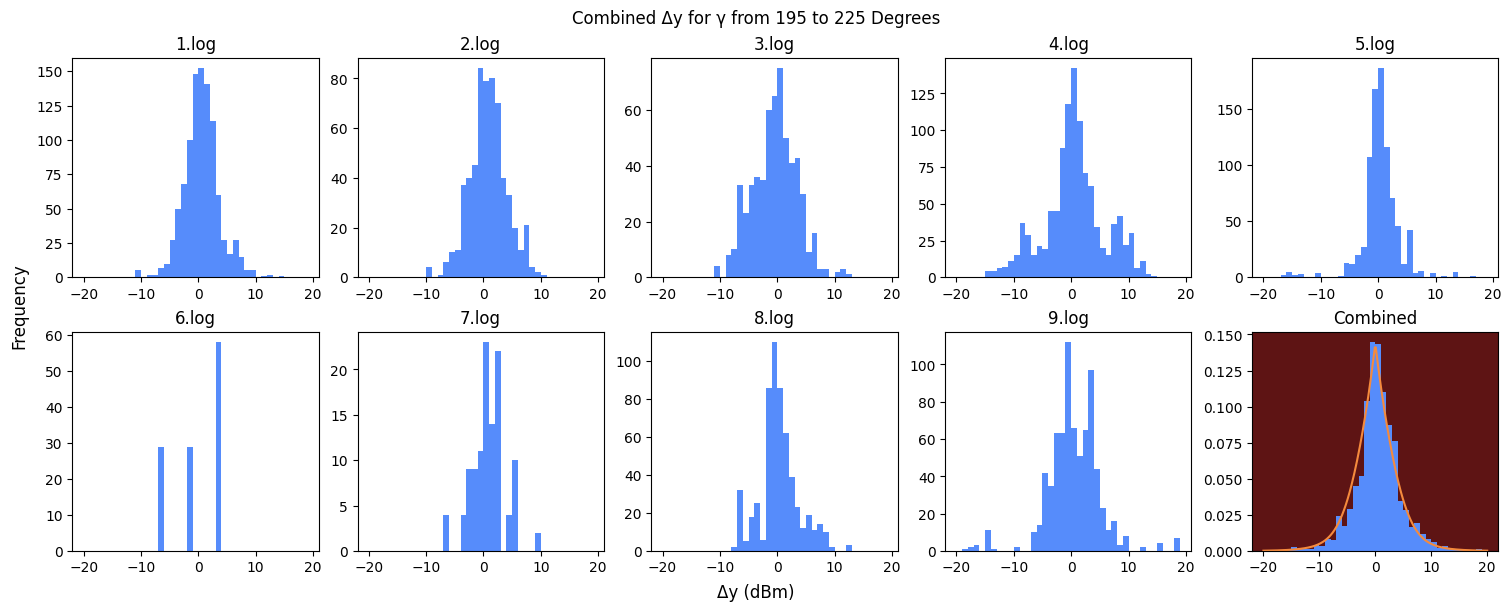

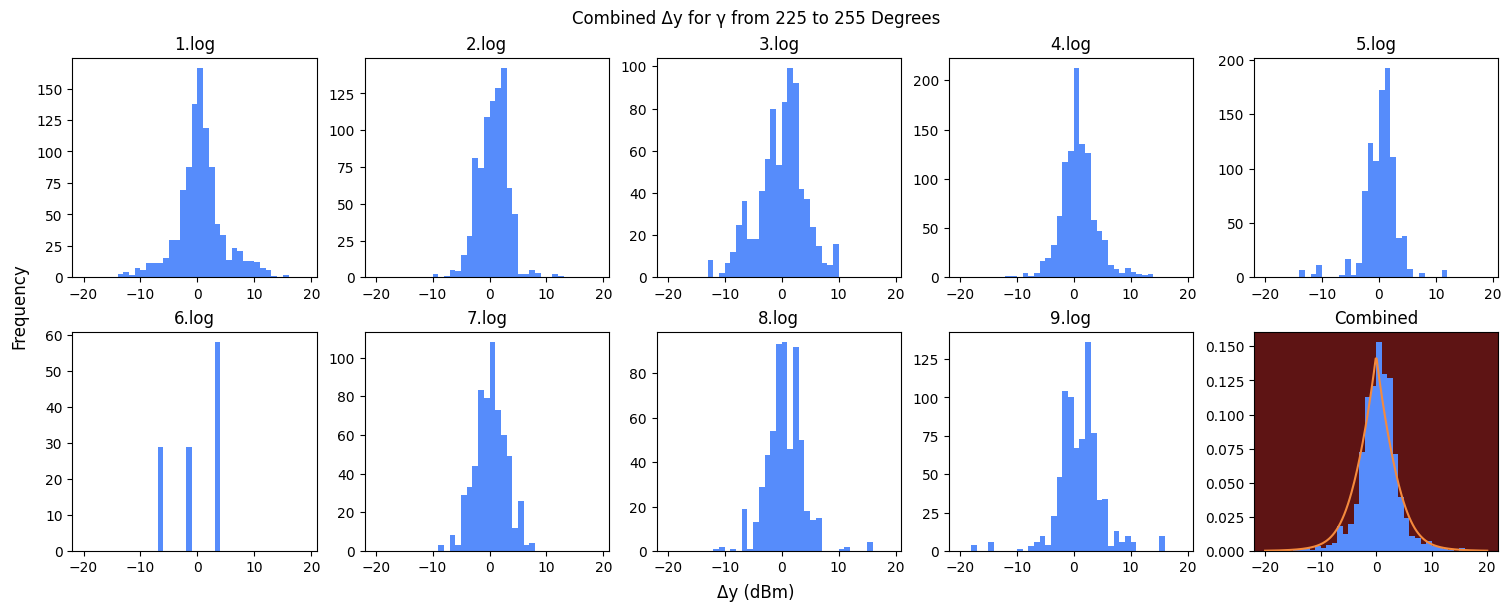

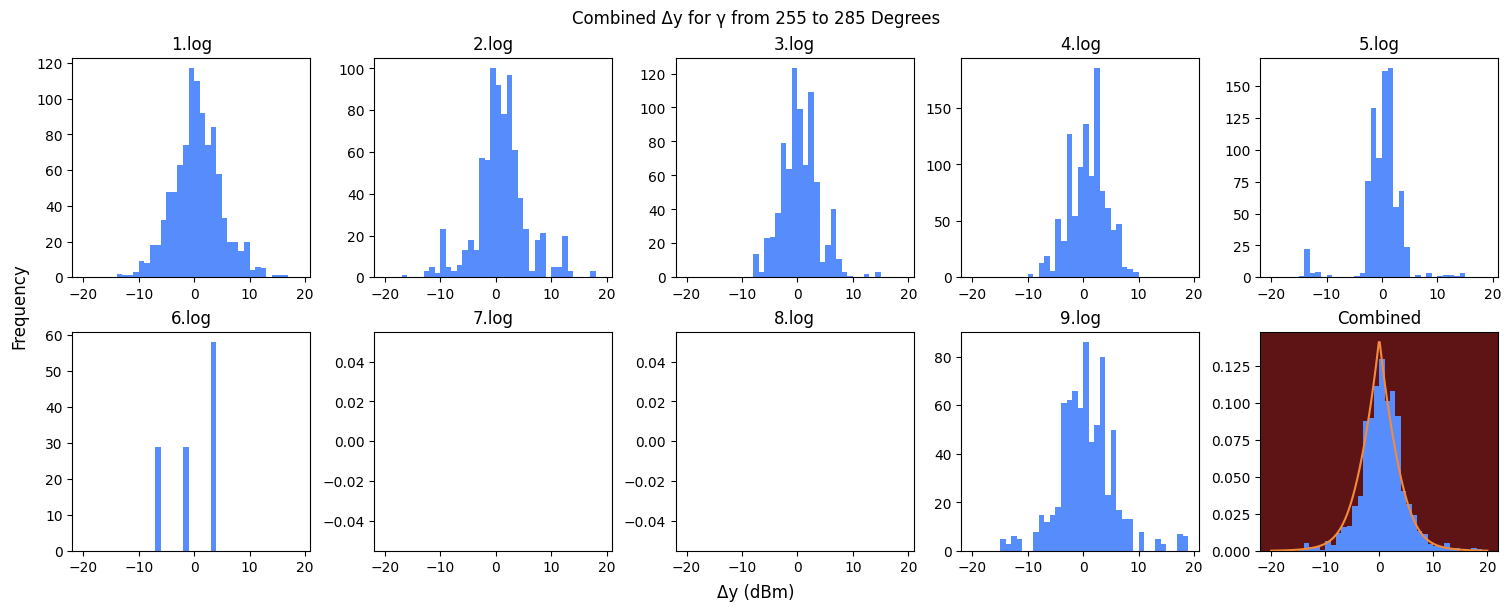

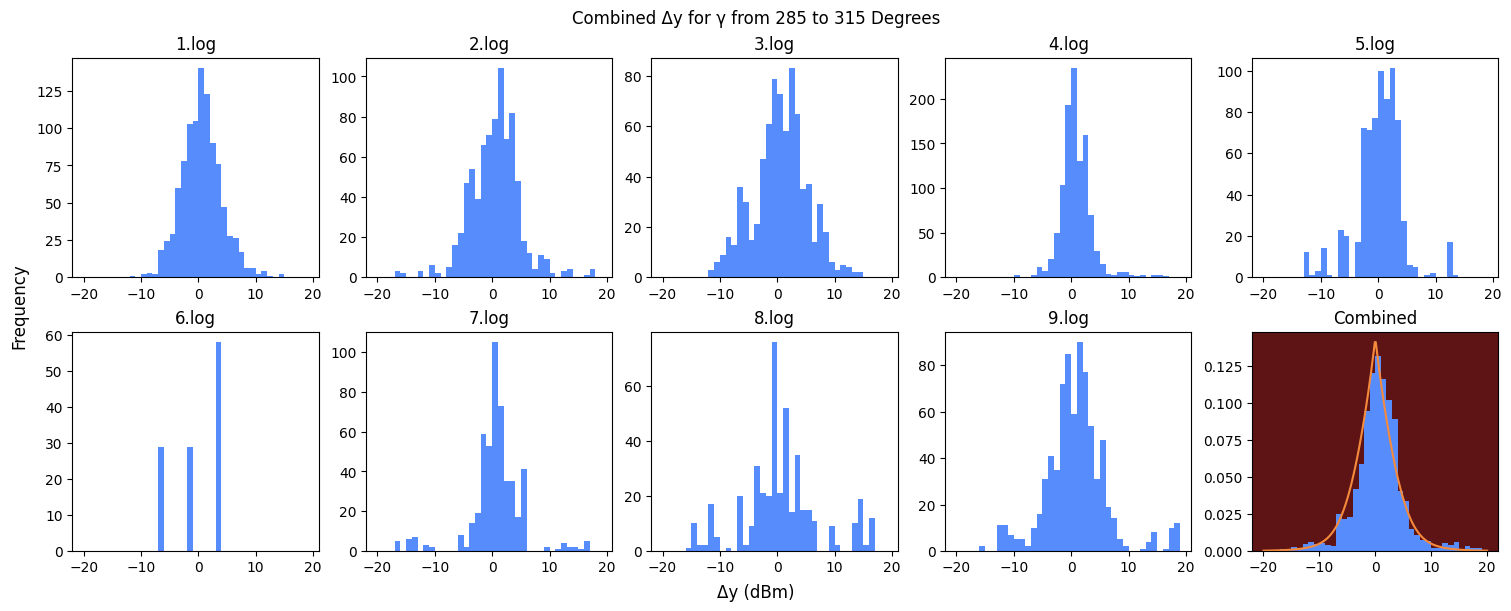

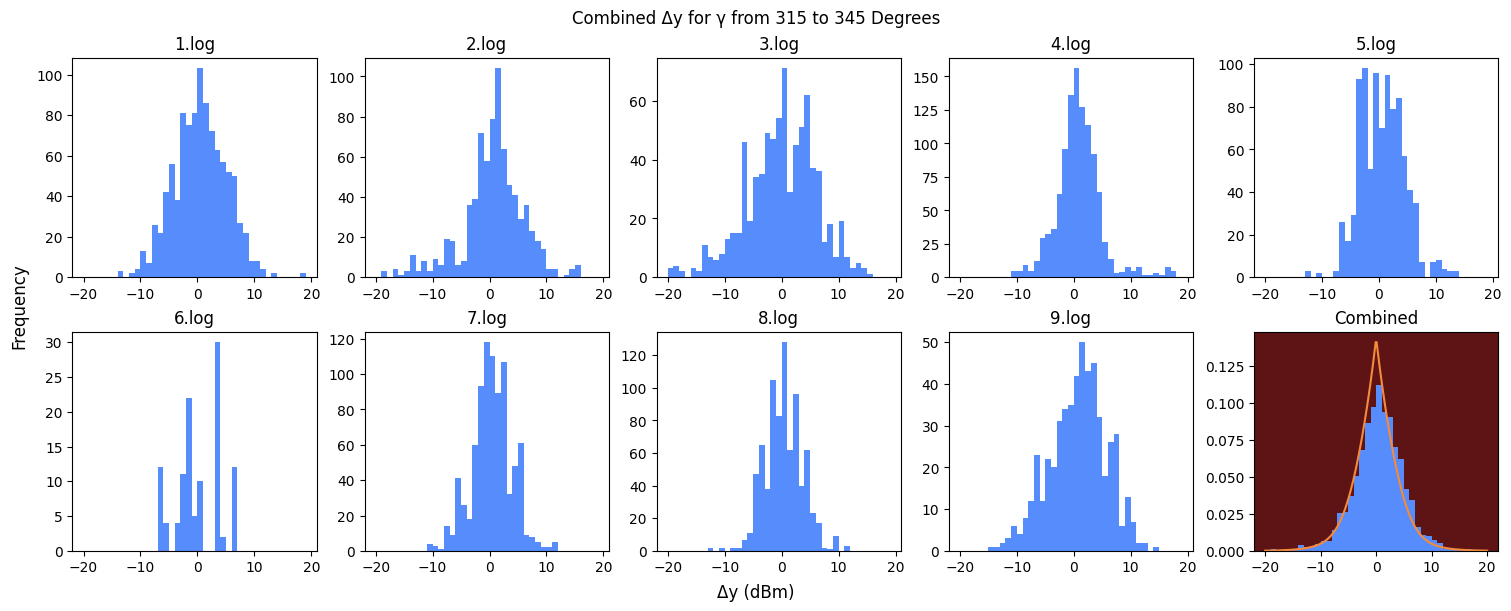

In [10]:
range_trial_rss_diffs_in_blocks(range_logs, 5)

### Ten Packet Differences

The difference is taken between the current packet and the packet at the same gamma in ten transmitter-rotations' time (approximately 20 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

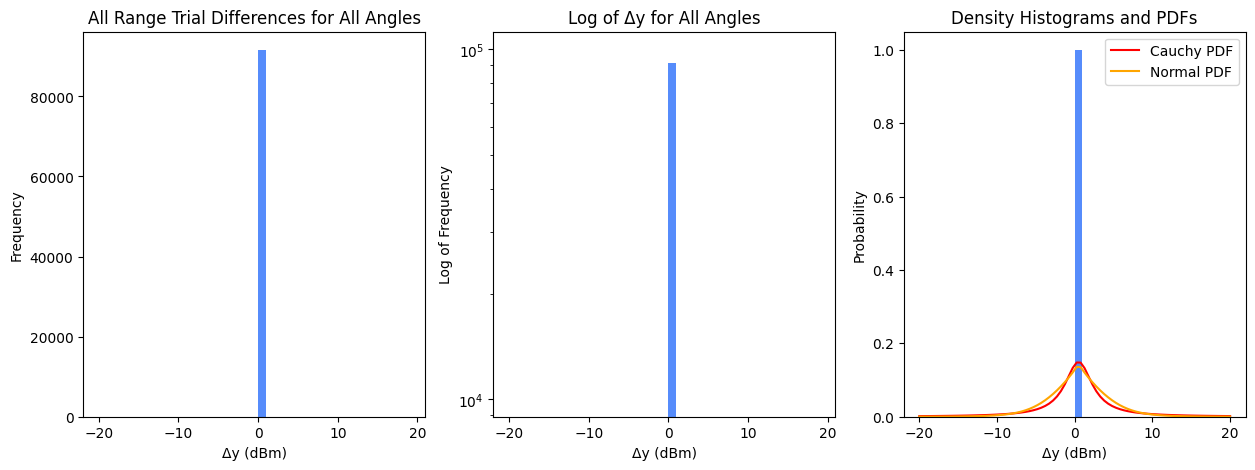

In [5]:
diffs_10 = combined_rss_at_gamma_analysis(range_logs, False)

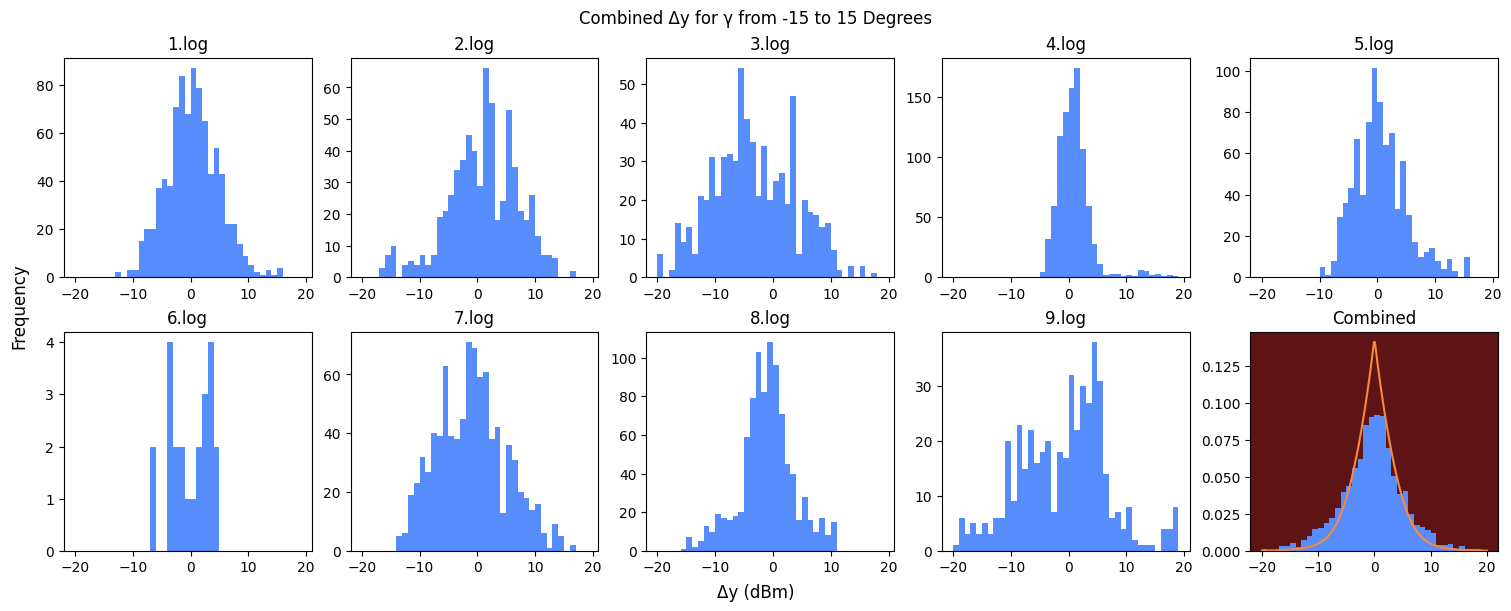

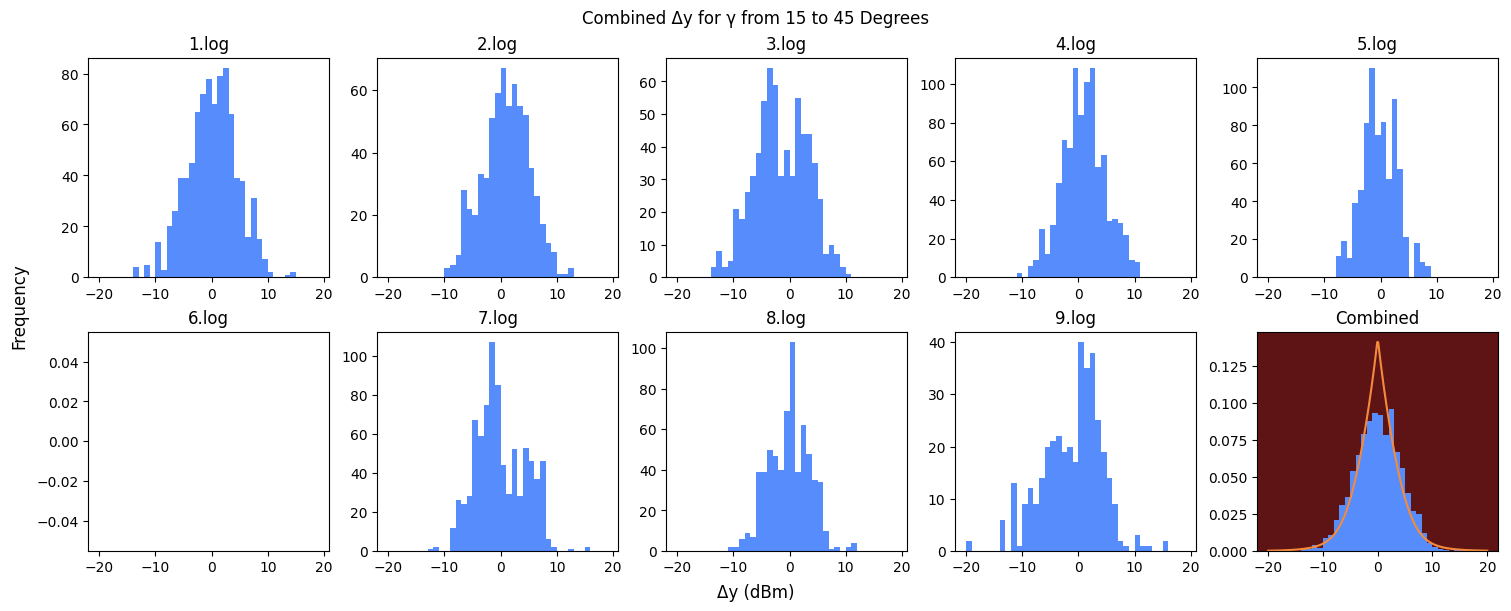

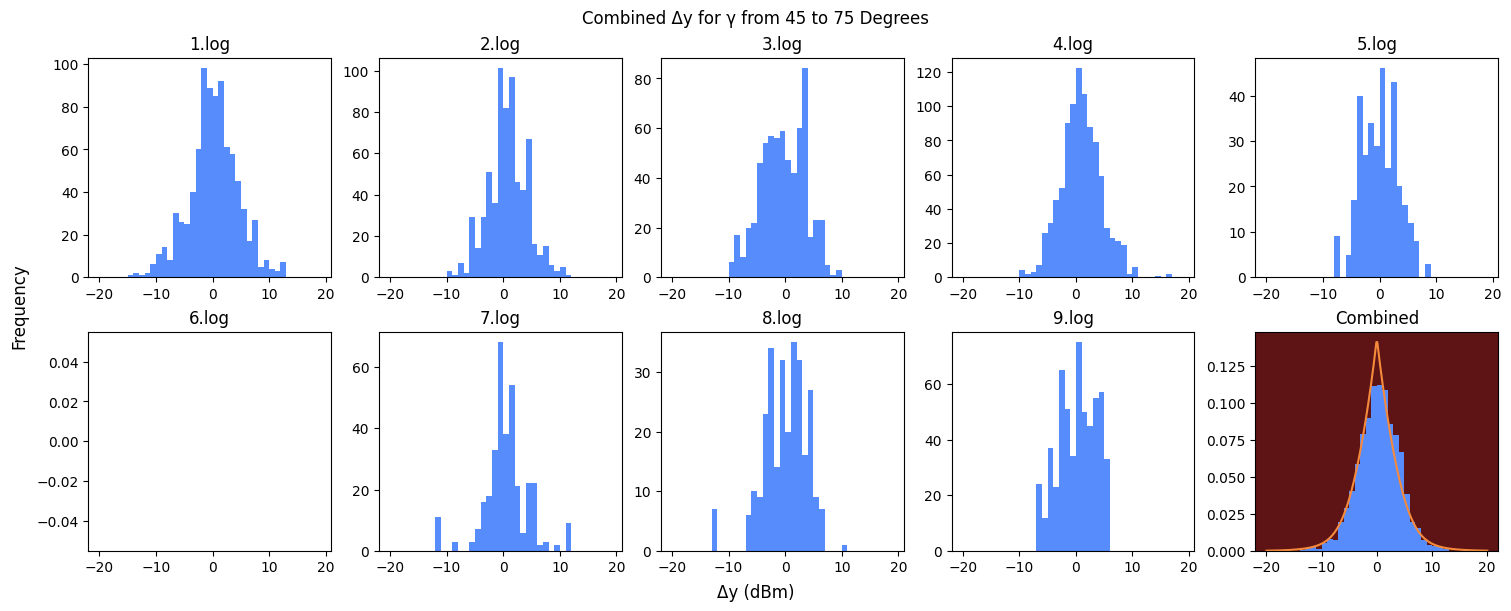

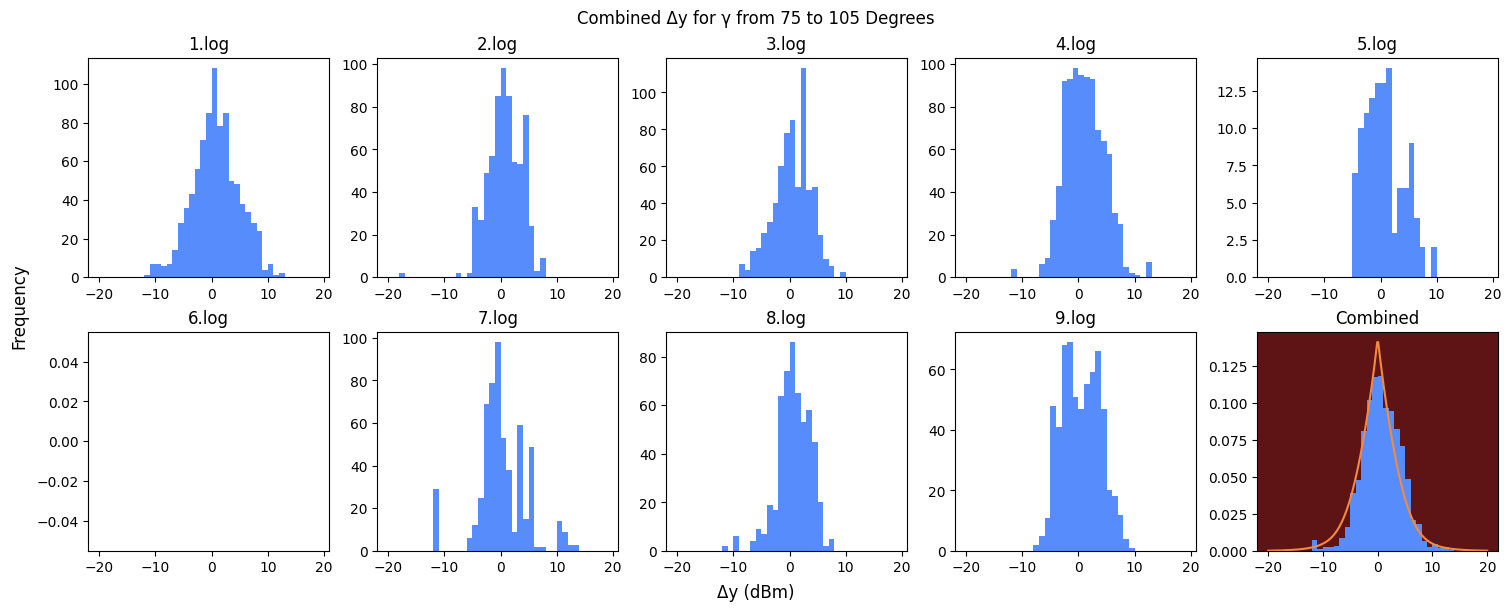

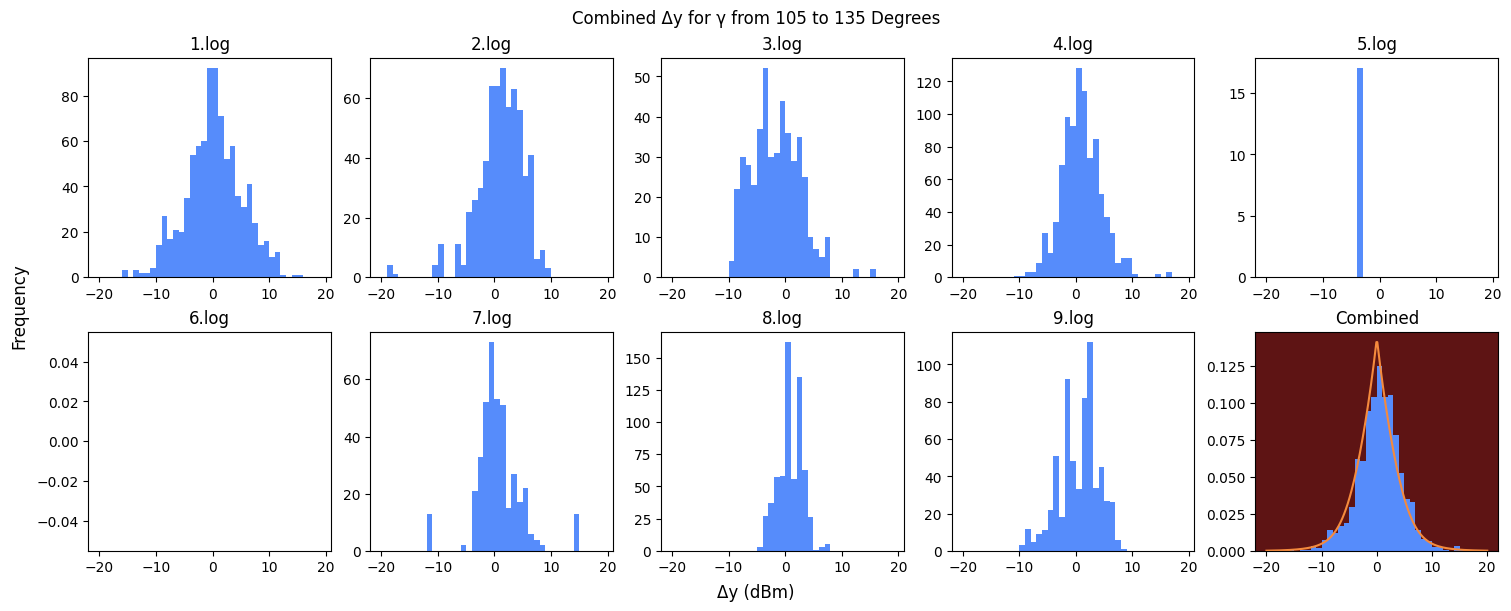

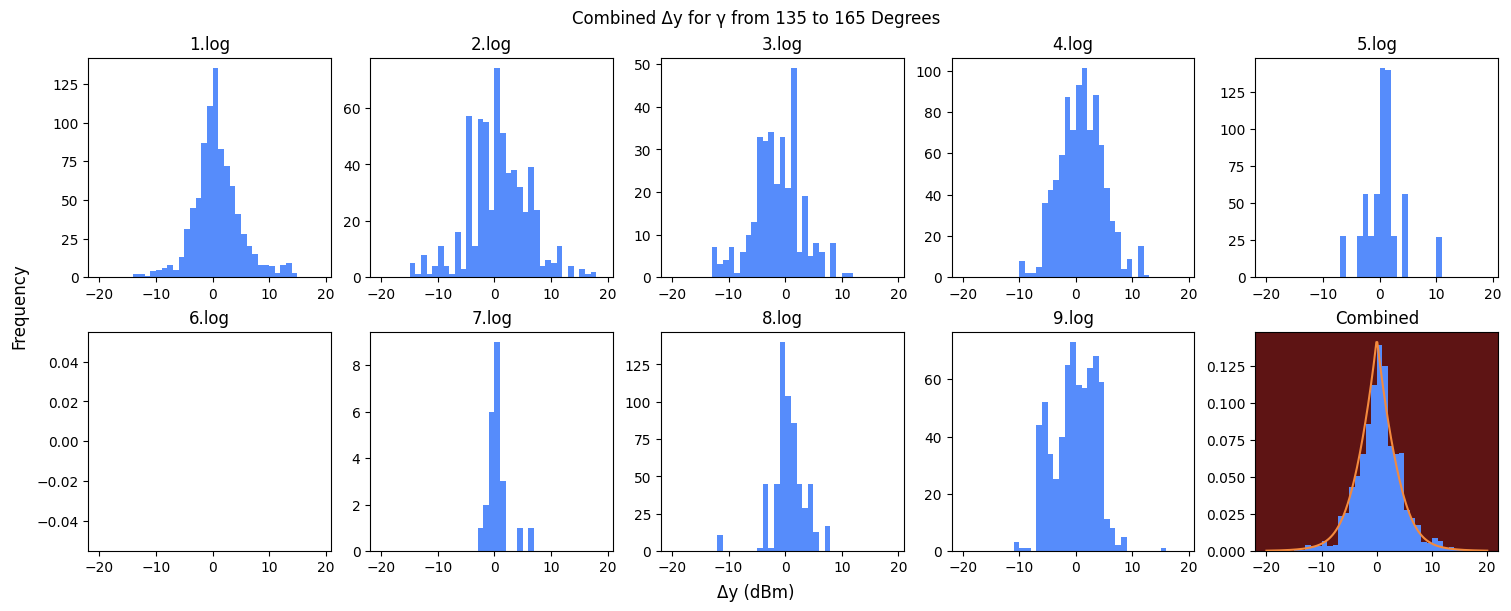

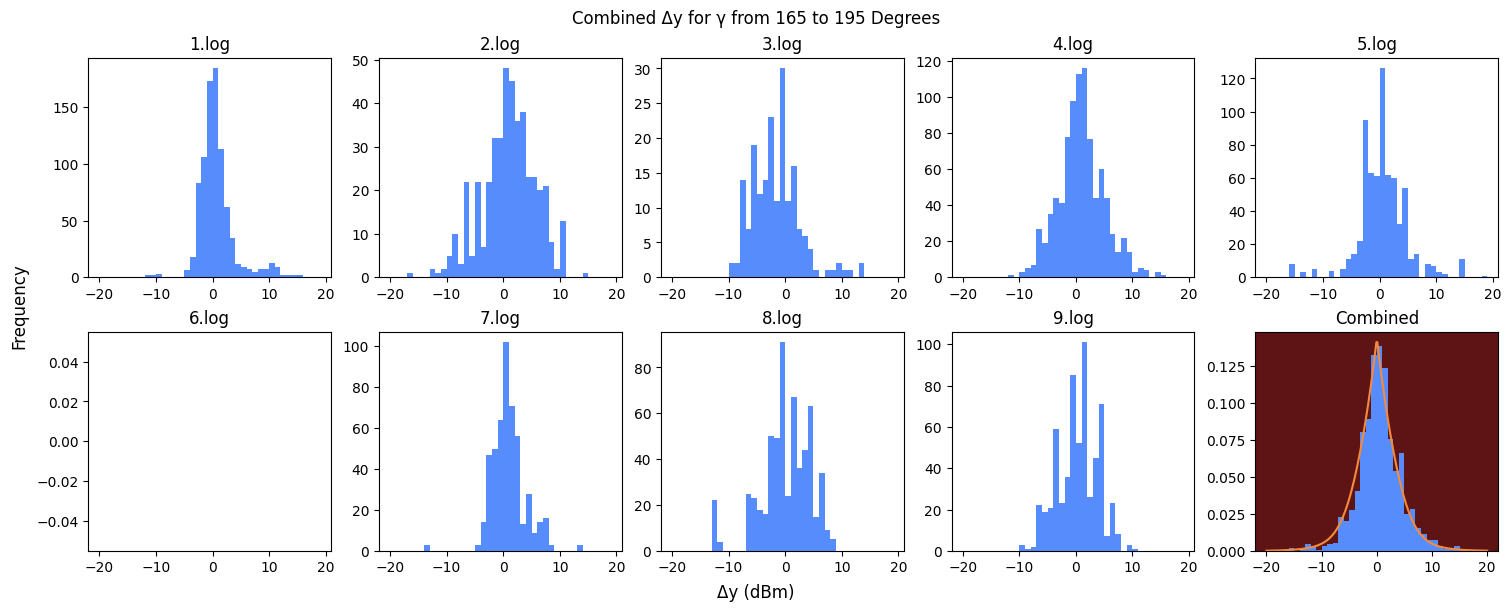

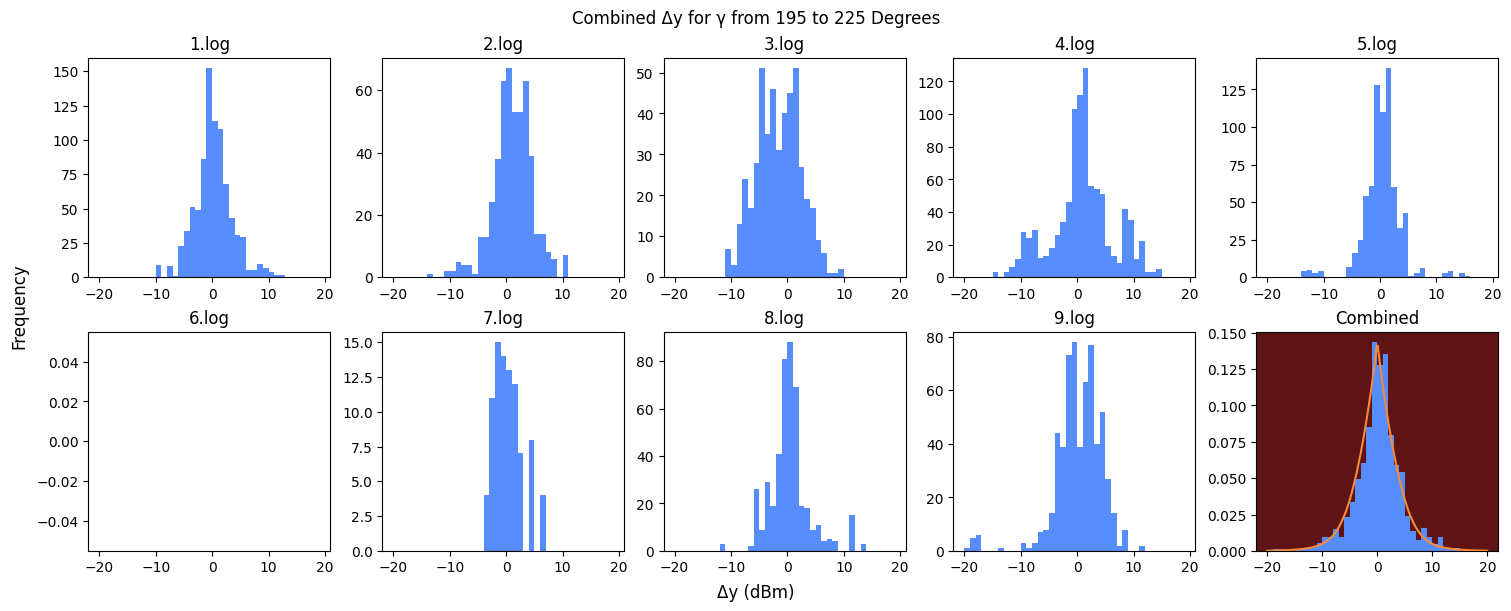

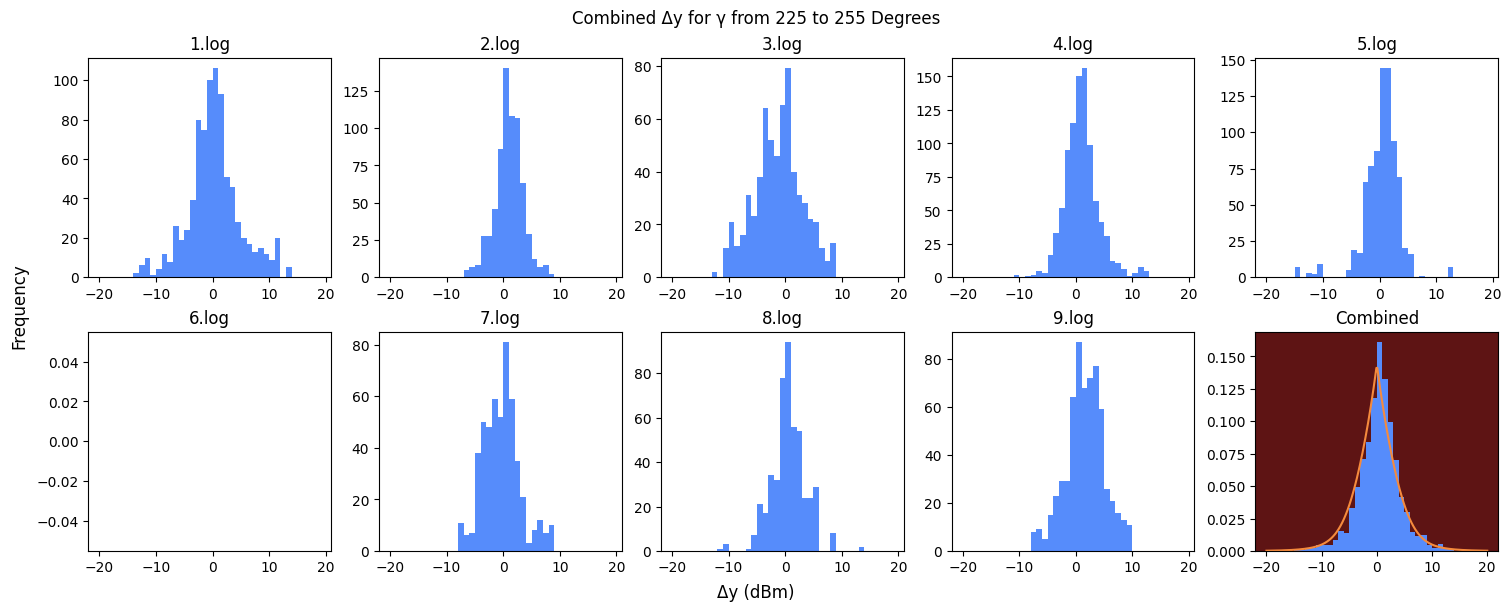

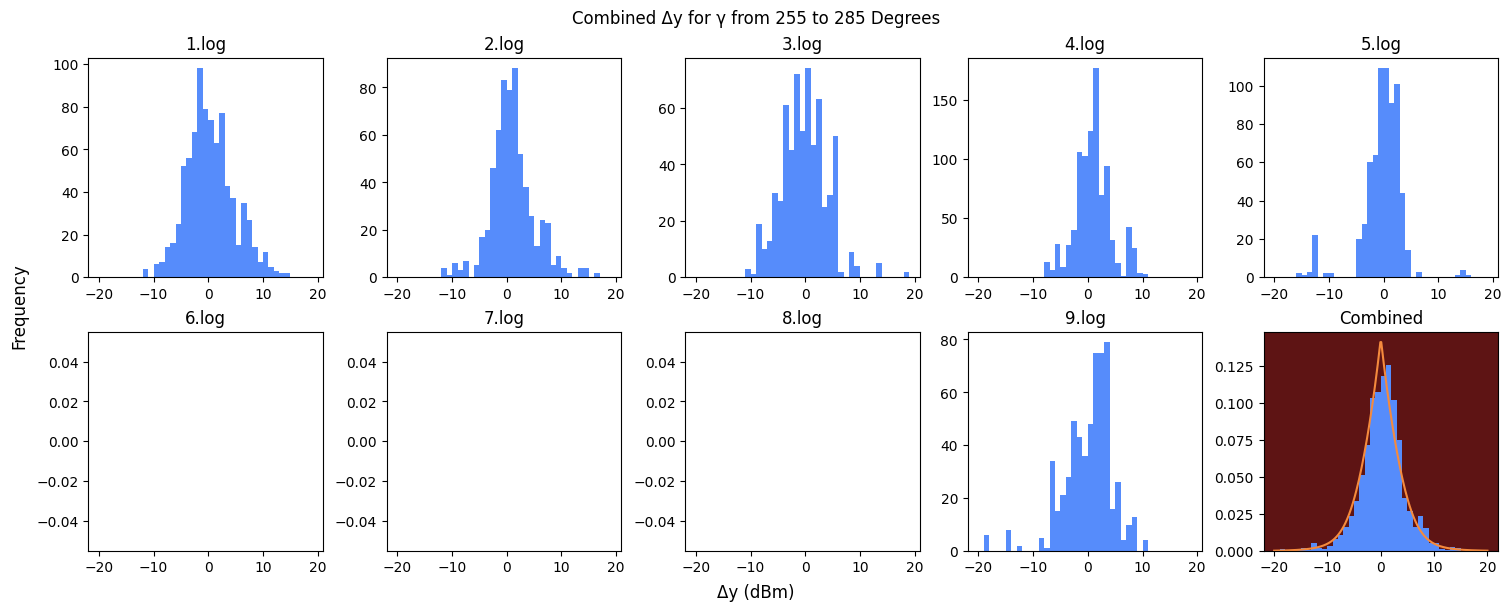

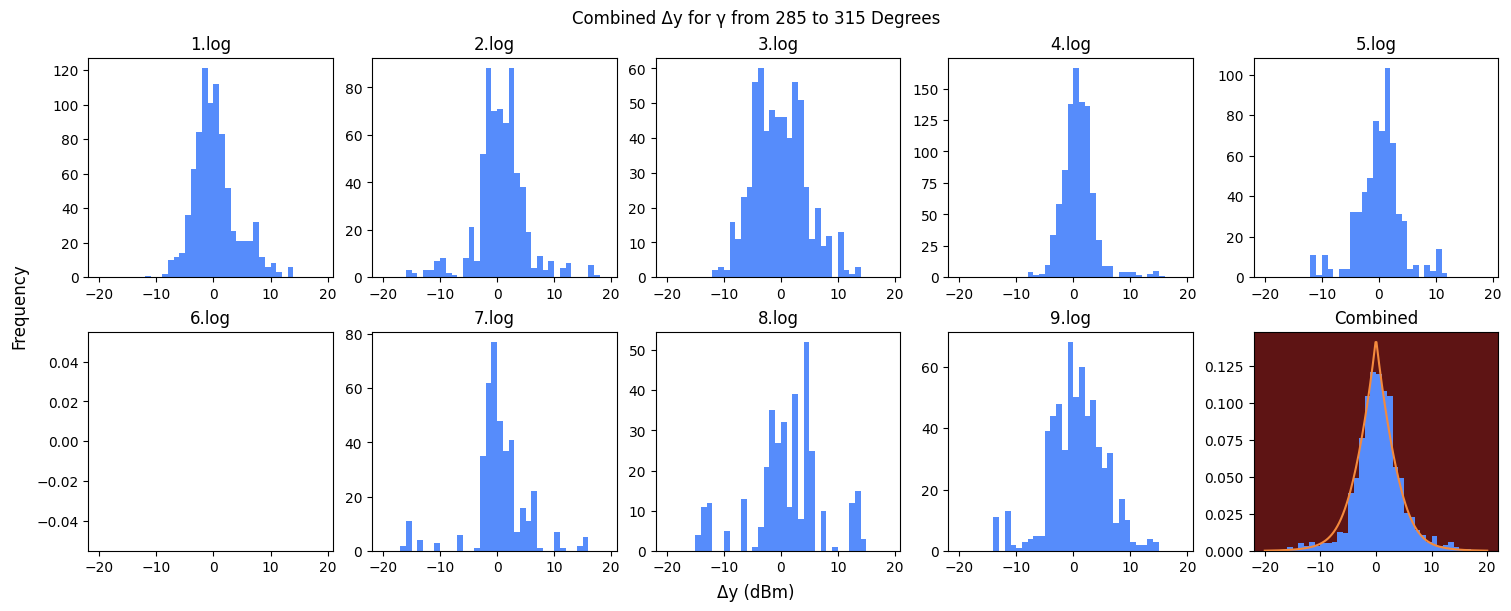

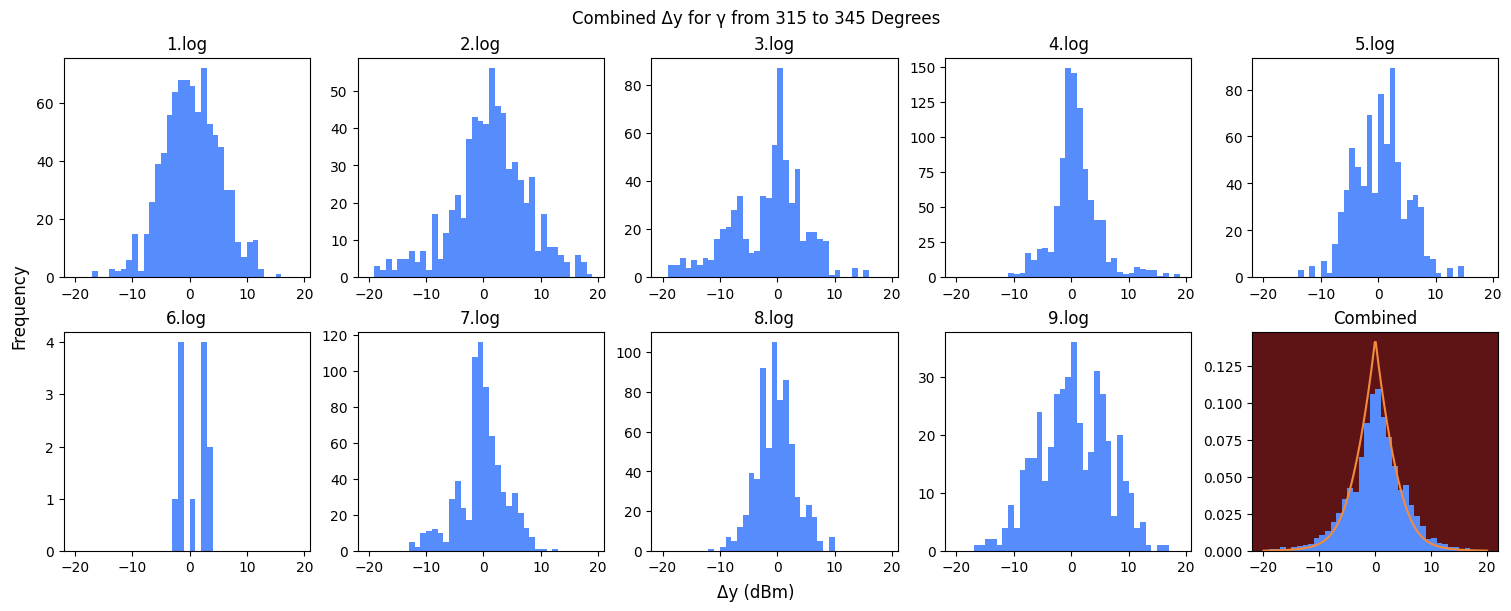

In [12]:
range_trial_rss_diffs_in_blocks(range_logs, 10)

### K-Means

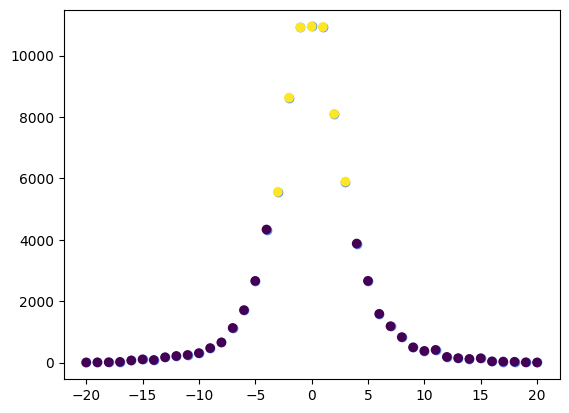

In [13]:
from sklearn.cluster import KMeans

freq_diff = [0] * 41 # [20] is diff of 0
rss = [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

for diff in diffs_2:
    try:
        freq_diff[diff + 20] += 1
    except:
        pass

plt.scatter(rss, freq_diff)

data = list(zip(rss, freq_diff))

kmeans = KMeans(n_clusters=2)
kmeans.fit(np.array(freq_diff).reshape(-1,1))

plt.scatter(rss, freq_diff, c=kmeans.labels_)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 47 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,-0.00,0.01,-0.01,0.01,0.0,0.0,50421.49,37593.26,1.0
std_posterior,1.77,0.01,1.76,1.78,0.0,0.0,50612.22,36984.09,1.0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 21 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.10,0.04,0.02,0.18,0.0,0.0,52709.00,36509.51,1.0
std_posterior,6.67,0.03,6.62,6.73,0.0,0.0,53206.55,38774.54,1.0


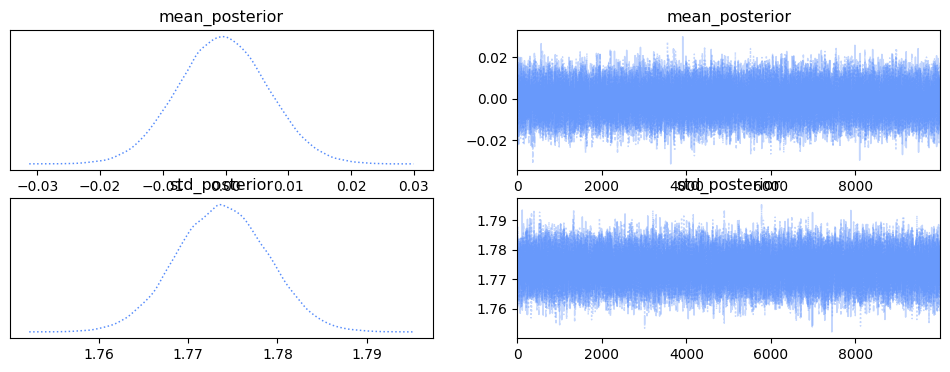

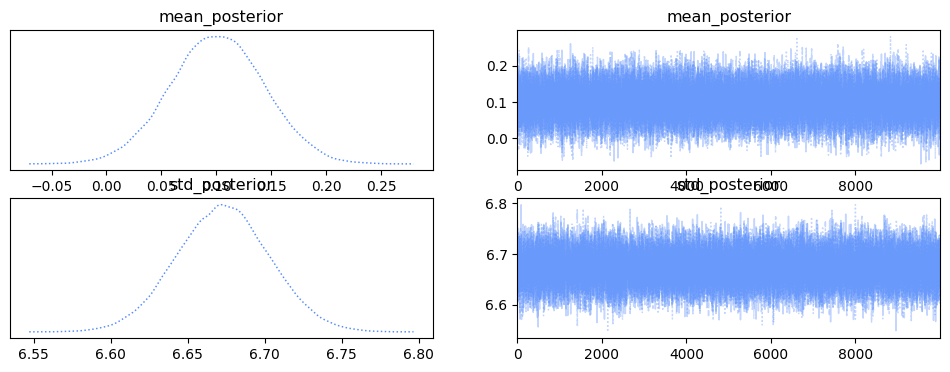

In [14]:
import pymc as pm
import arviz as az

diffs_pink = []

# filter out all "narrow" values
for diff in diffs_2:
    if -3 <= diff <= 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-3, upper=3)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-5, upper=5)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_pink = pm.sample(10_000, chains=5)

az.plot_trace(trace_pink, combined=True)
summary_pink = az.summary(trace_pink, round_to=2)
display(summary_pink)

diffs_pink = []

# filter out all "narrow" values
for diff in diffs_2:
    if diff < -3 or diff > 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-10, upper=10)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-17, upper=17)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_yellow = pm.sample(10_000, chains=5)

az.plot_trace(trace_yellow, combined=True)
summary_yellow = az.summary(trace_yellow, round_to=2)
display(summary_yellow)

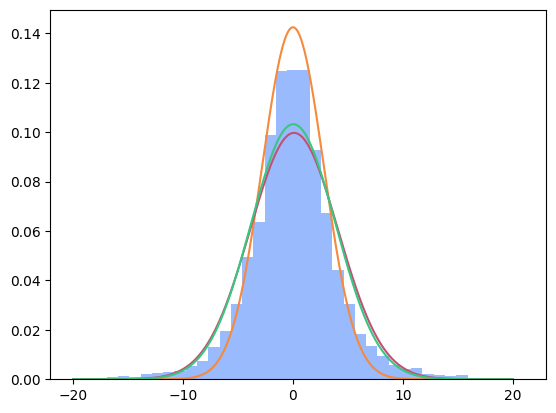

In [15]:
# plt.figure(figsize=(30, 30))
plt.hist(diffs_2, bins=40, alpha=0.6, density=True)

y_all = norm.pdf(x_axis, summary_pink.loc["mean_posterior", "mean"], 2.8)
y_wide = norm.pdf(x_axis, summary_yellow.loc["mean_posterior", "mean"],4.0)

plt.plot(x_axis, y_all)
plt.plot(x_axis, y_wide)

# normal over all diffs
all_mu, all_std = norm.fit(diffs_2)
all_norm = norm.pdf(x_axis, all_mu, all_std)
plt.plot(x_axis, all_norm)

plt.show()

## PyMC

Do inference on the data using PyMC to discover the true distribution of the data and that distribution's parameters

### Average $\Delta y$

In [16]:
d0_avg = np.mean(diffs_1)
d2_avg = np.mean(diffs_2)
d5_avg = np.mean(diffs_5)
d10_avg = np.mean(diffs_10)
total_avg = 0.25 * (d0_avg + d2_avg + d5_avg + d10_avg)

print(f"Means: \nD0: {d0_avg} \nD1: {d2_avg} \nD5: {d5_avg} \nD10: {d10_avg}")
print(f"Total Mean: {total_avg} or to 3SF: {total_avg:.4f}")

Means: 
D0: 0.02937248155023317 
D1: 0.02835997701176388 
D5: -0.013565203675223786 
D10: -0.18651291453568786
Total Mean: -0.03558641491222865 or to 3SF: -0.0356


### Normal

Just one normal distribution

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.749,0.009,3.733,3.766,0.0,0.0,2659.0,4457.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


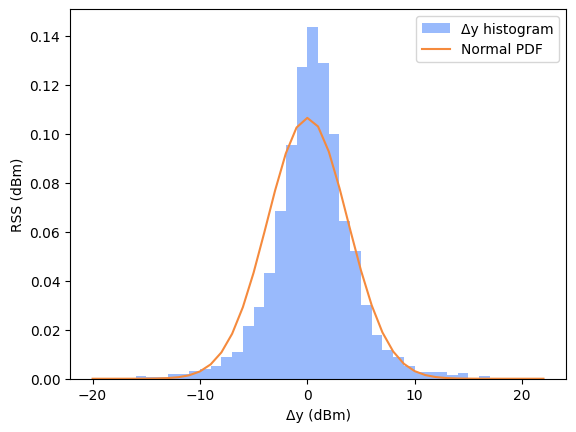

In [17]:
learn_normal(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.864,0.009,3.847,3.882,0.0,0.0,2656.0,4319.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


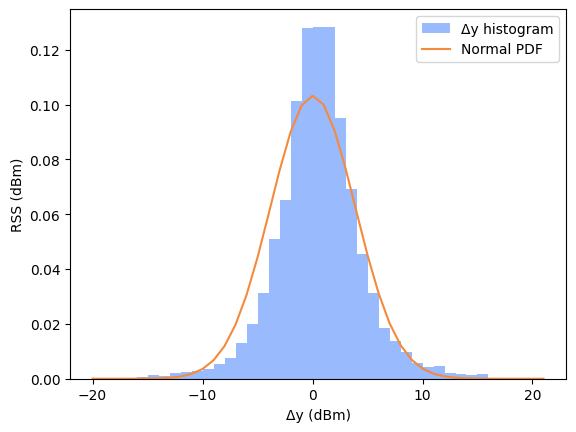

In [18]:
learn_normal(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,4.099,0.01,4.08,4.119,0.0,0.0,2567.0,4365.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


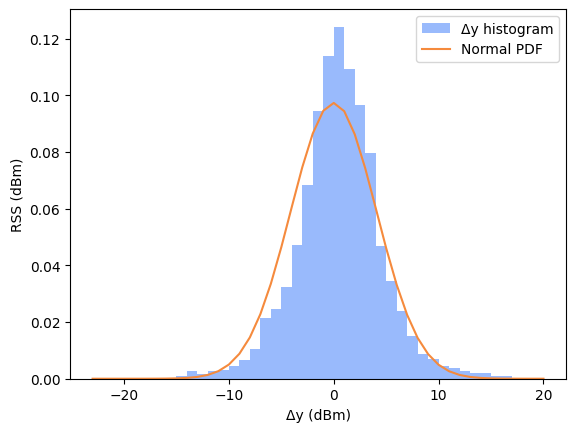

In [19]:
learn_normal(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,4.278,0.012,4.255,4.299,0.0,0.0,2811.0,4436.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


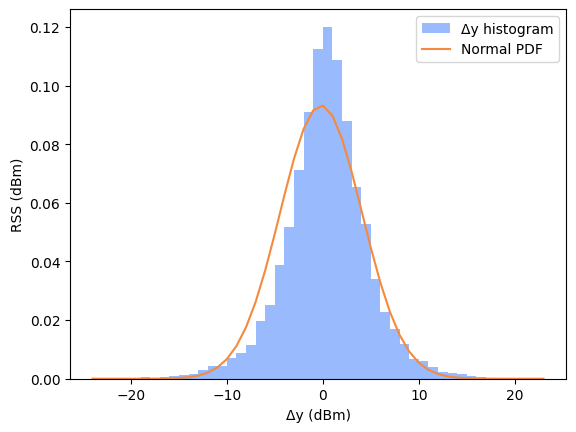

In [20]:
learn_normal(diffs_10)

### Two Normals

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 349 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.628,1.607,2.455,5.955,0.926,0.328,5.0,35.0,1.66
sigma2,4.765,1.608,2.466,5.989,0.927,0.327,5.0,40.0,1.66
w[0],0.575,0.213,0.265,0.738,0.123,0.043,5.0,38.0,1.66
w[1],0.425,0.213,0.262,0.735,0.123,0.043,5.0,38.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


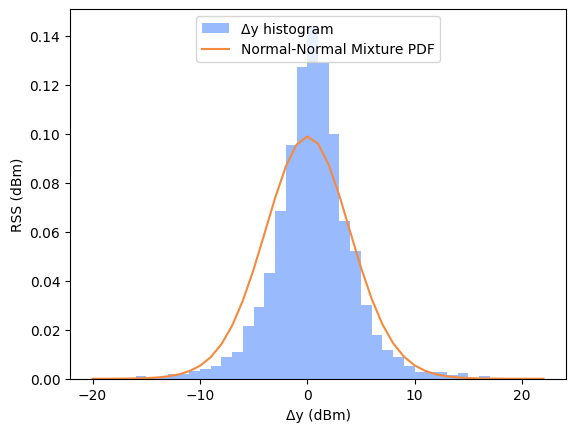

In [21]:
learn_norm_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 300 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.657,1.590,2.491,5.957,0.917,0.324,5.0,35.0,1.66
sigma2,4.783,1.593,2.499,5.989,0.918,0.324,5.0,38.0,1.66
w[0],0.567,0.190,0.290,0.715,0.109,0.039,5.0,36.0,1.66
w[1],0.433,0.190,0.285,0.710,0.109,0.039,5.0,36.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


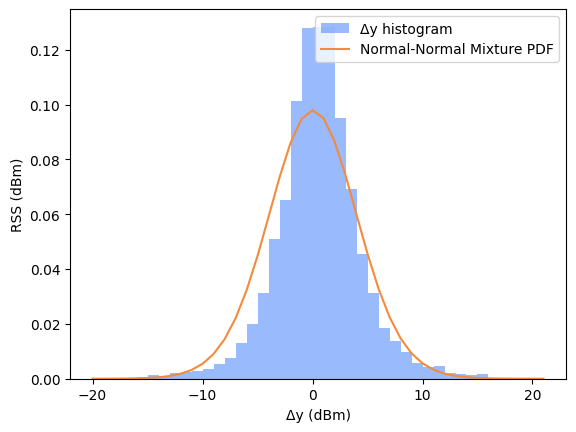

In [22]:
learn_norm_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 262 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,3.886,1.533,2.746,6.118,0.884,0.313,5.0,36.0,1.66
sigma2,4.967,1.531,2.762,6.148,0.882,0.311,5.0,41.0,1.66
w[0],0.562,0.178,0.298,0.706,0.103,0.036,5.0,39.0,1.66
w[1],0.438,0.178,0.294,0.702,0.103,0.036,5.0,39.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


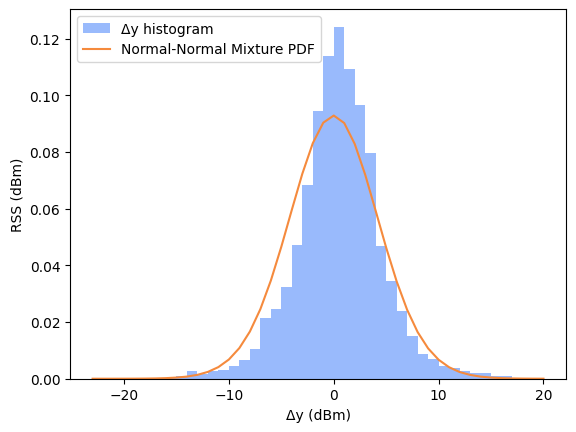

In [23]:
learn_norm_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma1, sigma2]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 207 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma1,4.882,1.496,2.720,6.034,0.862,0.305,5.0,38.0,1.66
sigma2,3.824,1.495,2.705,6.003,0.861,0.305,5.0,36.0,1.66
w[0],0.462,0.109,0.365,0.630,0.062,0.022,5.0,37.0,1.66
w[1],0.538,0.109,0.370,0.635,0.062,0.022,5.0,37.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


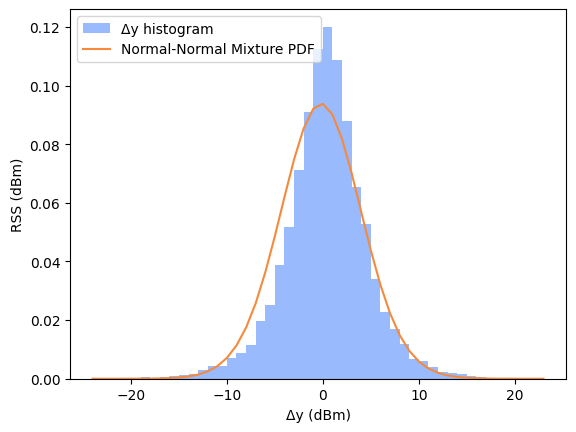

In [24]:
learn_norm_norm_mix(diffs_10)

### Three Normals

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 631 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],4.654,2.359,1.240,6.454,1.359,0.480,5.0,42.0,1.66
sigma[1],2.987,2.361,1.200,6.415,1.360,0.481,5.0,38.0,1.67
sigma[2],2.909,0.041,2.837,2.992,0.001,0.001,1466.0,1852.0,1.00
w[0],0.181,0.036,0.117,0.222,0.020,0.008,5.0,40.0,1.66
w[1],0.156,0.037,0.110,0.218,0.020,0.006,5.0,37.0,1.66
w[2],0.662,0.013,0.638,0.687,0.000,0.000,2151.0,3305.0,1.00


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


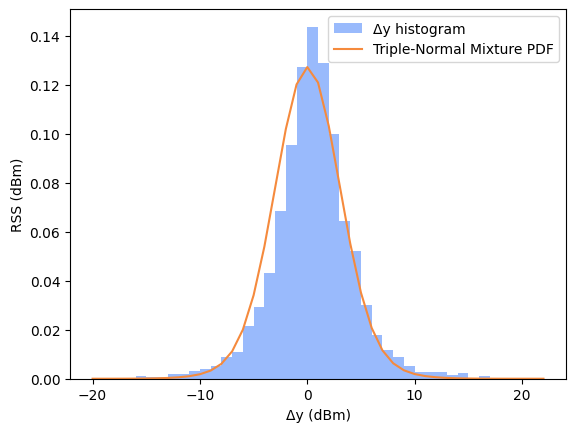

In [25]:
learn_triple_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 1066 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],3.998,1.544,2.805,6.256,0.889,0.314,5.0,35.0,1.66
sigma[1],1.621,0.092,1.460,1.808,0.002,0.001,1594.0,2186.0,1.00
sigma[2],5.089,1.548,2.830,6.300,0.891,0.315,5.0,38.0,1.67
w[0],0.487,0.171,0.232,0.642,0.098,0.034,5.0,36.0,1.66
w[1],0.145,0.027,0.095,0.194,0.001,0.000,1414.0,1990.0,1.00
w[2],0.367,0.172,0.226,0.634,0.099,0.035,5.0,46.0,1.66


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


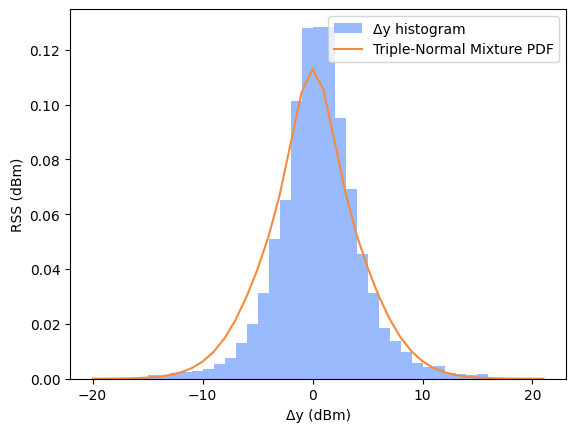

In [26]:
learn_triple_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 748 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],4.427,1.462,3.263,6.598,0.841,0.298,5.0,40.0,1.66
sigma[1],3.477,2.130,1.822,6.597,1.226,0.434,5.0,37.0,1.67
sigma[2],3.952,1.885,1.854,6.605,1.085,0.384,4.0,39.0,2.37
w[0],0.456,0.166,0.205,0.612,0.095,0.033,5.0,43.0,1.66
w[1],0.212,0.027,0.155,0.256,0.005,0.003,36.0,518.0,1.07
w[2],0.332,0.169,0.163,0.605,0.096,0.034,4.0,33.0,1.88


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


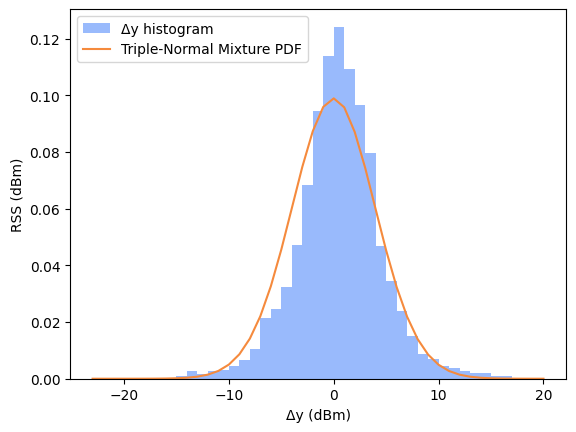

In [27]:
learn_triple_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 543 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],2.904,2.316,1.053,6.277,1.333,0.470,5.0,39.0,1.66
sigma[1],4.537,2.311,1.121,6.316,1.331,0.471,5.0,50.0,1.66
sigma[2],3.108,0.065,2.989,3.235,0.002,0.001,1277.0,1929.0,1.00
w[0],0.153,0.121,0.044,0.339,0.069,0.024,5.0,36.0,1.66
w[1],0.239,0.121,0.051,0.350,0.069,0.024,5.0,55.0,1.66
w[2],0.608,0.015,0.579,0.635,0.000,0.000,2736.0,3785.0,1.00


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


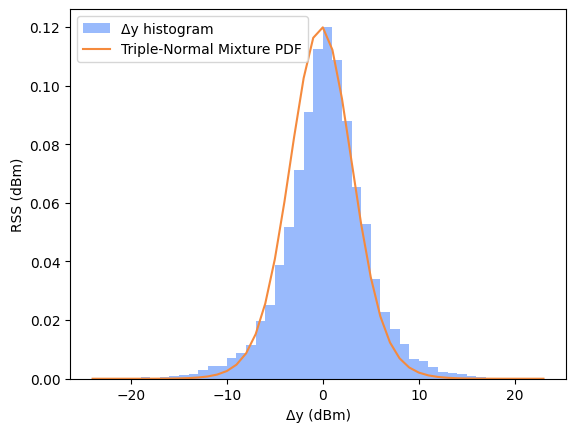

In [28]:
learn_triple_norm_mix(diffs_10)

### Cauchy Distribution

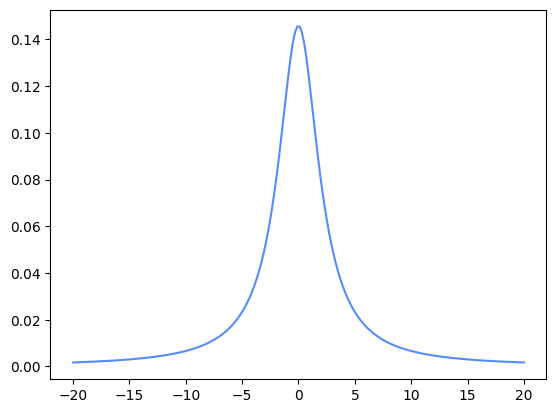

In [29]:
from scipy.stats import cauchy

x_axis = np.linspace(-20, 20, 40*5)
y_e1 = cauchy.pdf(x_axis, scale=2.183)

plt.plot(x_axis, y_e1)
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.855,0.008,1.838,1.87,0.0,0.0,2432.0,4303.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


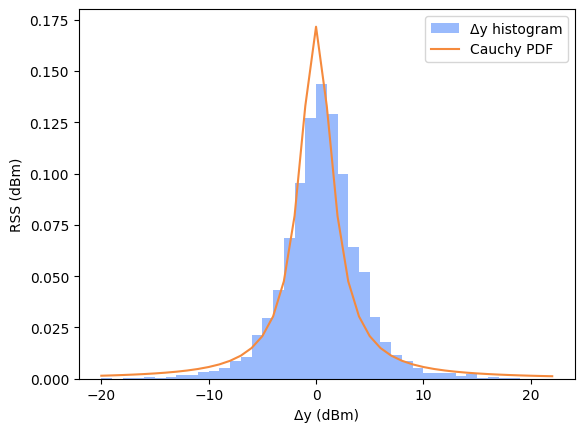

In [30]:
learn_cauchy(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.94,0.009,1.923,1.956,0.0,0.0,2416.0,4183.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


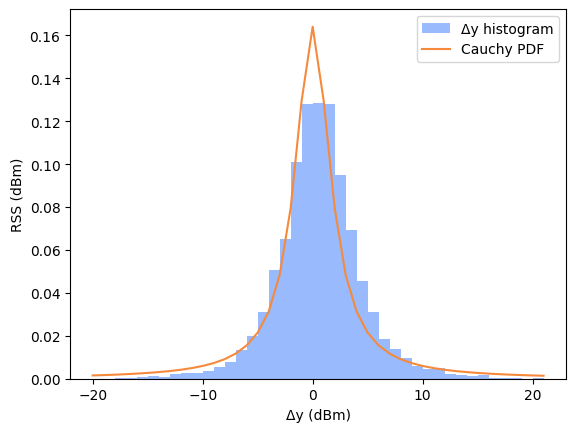

In [31]:
learn_cauchy(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.123,0.01,2.104,2.142,0.0,0.0,2422.0,4082.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


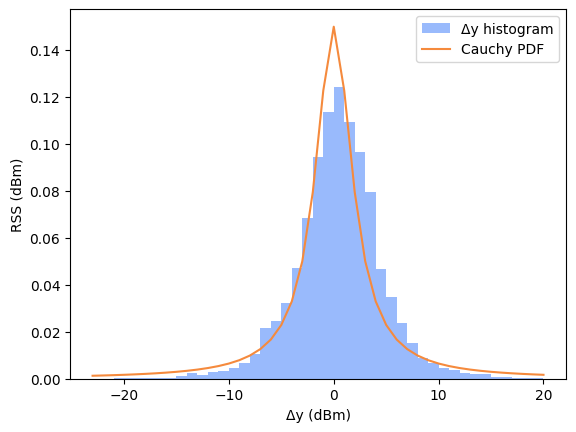

In [32]:
learn_cauchy(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [beta]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.212,0.011,2.191,2.234,0.0,0.0,2799.0,3830.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


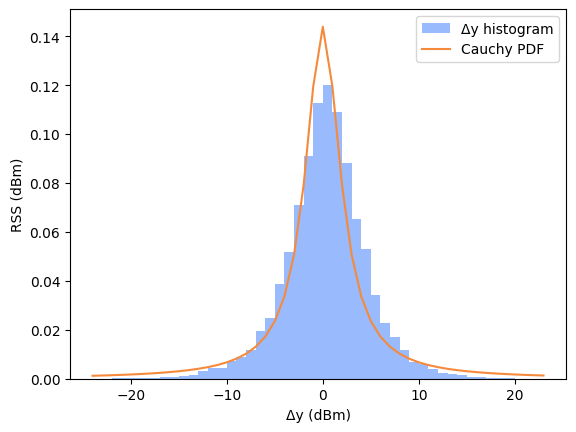

In [33]:
learn_cauchy(diffs_10)

### Cauchy and Normal Mixture Model

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 263 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.152,0.022,1.110,1.193,0.001,0.0,1662.0,1569.0,1.0
sigma,3.550,0.016,3.520,3.578,0.000,0.0,1884.0,1797.0,1.0
w[0],0.742,0.005,0.733,0.750,0.000,0.0,1757.0,1856.0,1.0
w[1],0.258,0.005,0.250,0.267,0.000,0.0,1757.0,1856.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


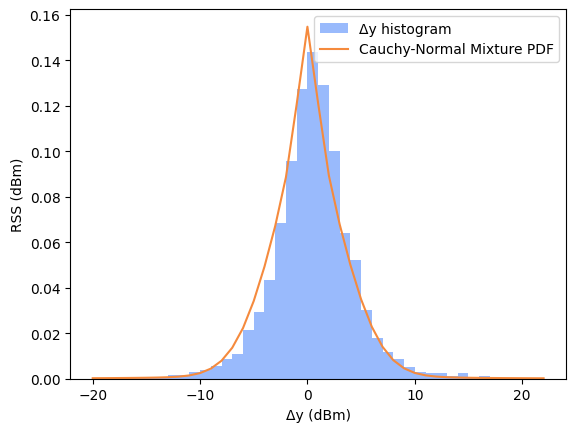

In [34]:
learn_cauchy_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 207 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.304,0.023,1.261,1.347,0.001,0.0,1880.0,1917.0,1.0
sigma,3.647,0.017,3.616,3.678,0.000,0.0,1953.0,2029.0,1.0
w[0],0.754,0.005,0.745,0.763,0.000,0.0,2389.0,2145.0,1.0
w[1],0.246,0.005,0.237,0.255,0.000,0.0,2389.0,2145.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


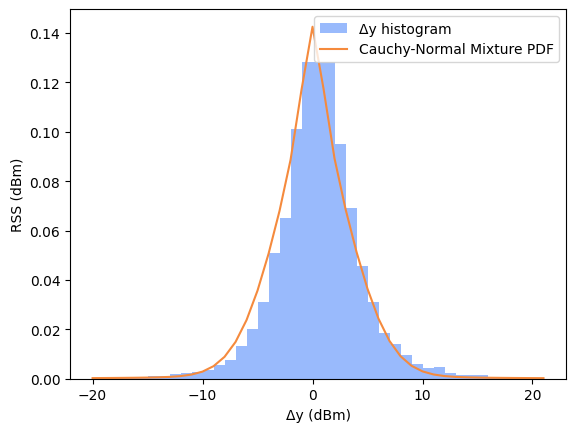

In [35]:
learn_cauchy_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 182 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,0.827,0.576,0.013,1.276,0.331,0.117,5.0,37.0,1.67
sigma,4.102,0.173,3.953,4.362,0.099,0.035,5.0,37.0,1.66
w[0],0.829,0.036,0.796,0.882,0.021,0.007,5.0,41.0,1.67
w[1],0.171,0.036,0.118,0.204,0.021,0.007,5.0,41.0,1.67


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


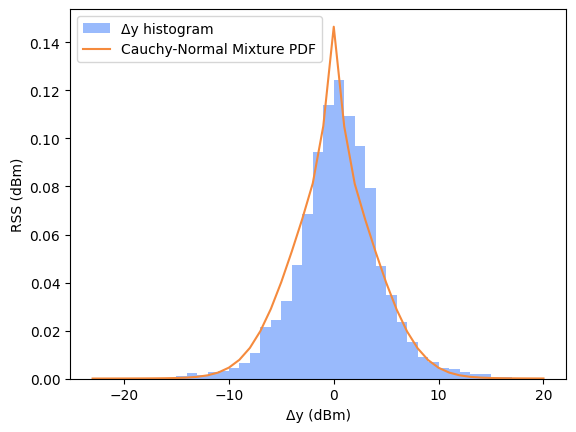

In [36]:
learn_cauchy_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, beta]


Output()

Sampling 3 chains for 2_000 tune and 1_000 draw iterations (6_000 + 3_000 draws total) took 146 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.119,0.030,1.063,1.175,0.001,0.001,1955.0,2032.0,1.0
sigma,4.273,0.018,4.241,4.306,0.000,0.000,2000.0,2033.0,1.0
w[0],0.811,0.005,0.801,0.822,0.000,0.000,2229.0,2064.0,1.0
w[1],0.189,0.005,0.178,0.199,0.000,0.000,2229.0,2064.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


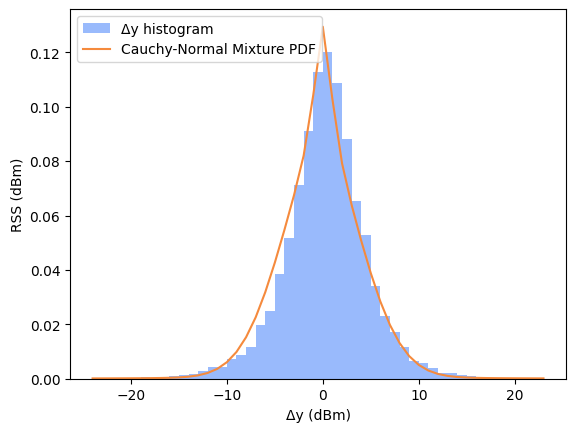

In [37]:
learn_cauchy_norm_mix(diffs_10)

#### Manual Parameter Experimentation

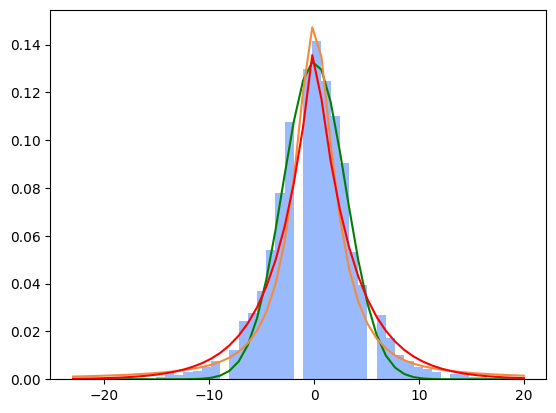

In [38]:
from scipy.stats import laplace

x_vals = np.linspace(min(diffs_5), max(diffs_5))
plt.hist(diffs_5, bins=x_vals, alpha=0.6, density=True)

c = cauchy.pdf(x_vals, scale=2.123)
n = norm.pdf(x_vals, 0, 3)
l = laplace.pdf(x_vals, loc=0, scale=3.5)

mix = 0.1 * n + 0.9 * c
# mix = (1 - 10**-10) * n + 10**-10 * c

# plt.plot(x_vals, c, 'red')
plt.plot(x_vals, n, 'green')
plt.plot(x_vals, mix)
plt.plot(x_vals, l, 'red')
plt.show()

### Laplace

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,2.695,0.009,2.678,2.712,0.0,0.0,2688.0,3902.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


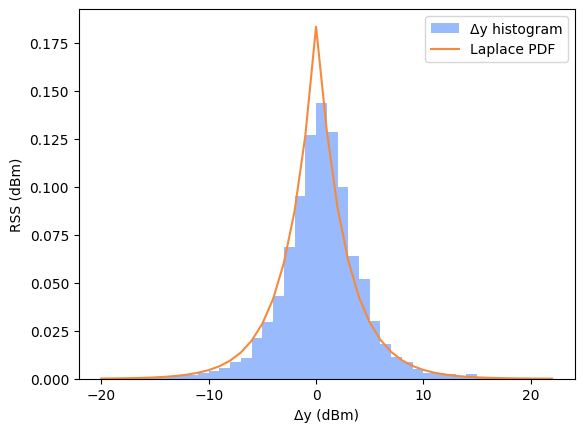

In [39]:
learn_laplace(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,2.8,0.01,2.782,2.818,0.0,0.0,2484.0,4096.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


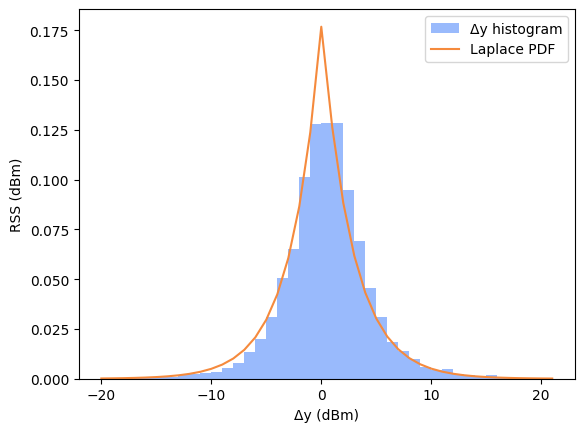

In [40]:
learn_laplace(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,3.012,0.011,2.992,3.032,0.0,0.0,2657.0,4215.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


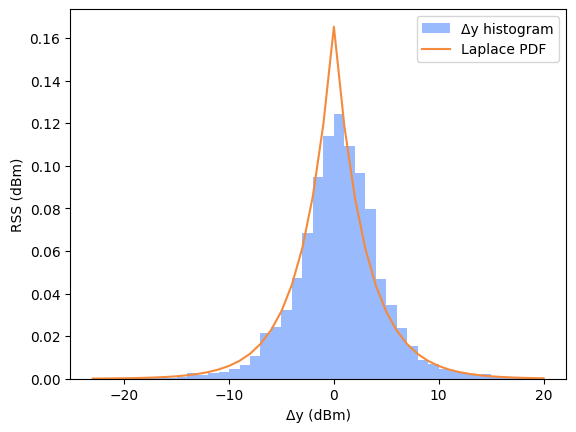

In [41]:
learn_laplace(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [std]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
std,3.169,0.013,3.144,3.192,0.0,0.0,2361.0,4174.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


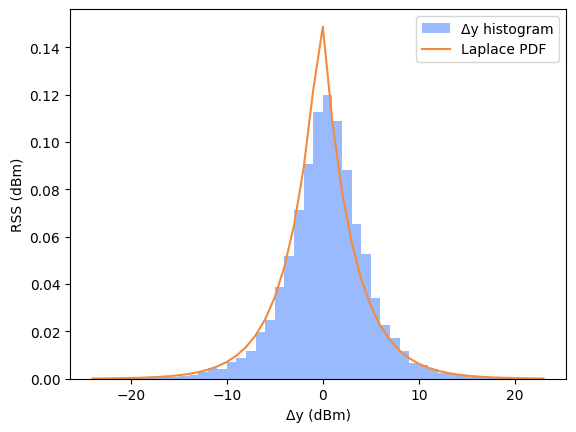

In [42]:
learn_laplace(diffs_10)

### Laplace and Normal Mixture

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 218 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,2.839,0.019,2.803,2.874,0.000,0.0,3967.0,5249.0,1.0
sigma,2.864,0.037,2.796,2.936,0.001,0.0,4534.0,5720.0,1.0
w[0],0.263,0.013,0.237,0.286,0.000,0.0,3985.0,5106.0,1.0
w[1],0.737,0.013,0.714,0.763,0.000,0.0,3985.0,5106.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


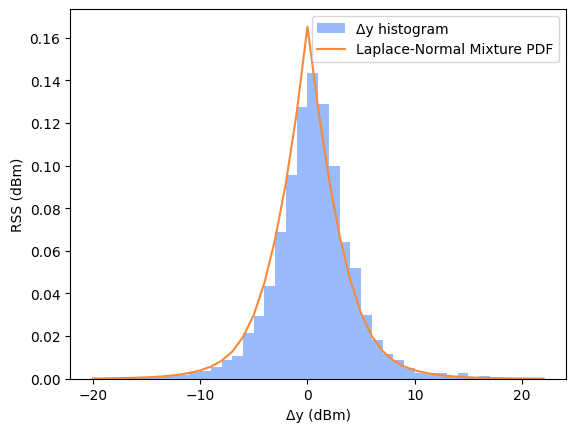

In [43]:
learn_laplace_norm_mix(diffs_1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 224 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.036,0.024,2.992,3.082,0.0,0.0,4593.0,5221.0,1.0
sigma,2.889,0.032,2.831,2.951,0.0,0.0,5067.0,5760.0,1.0
w[0],0.326,0.013,0.302,0.352,0.0,0.0,4794.0,5655.0,1.0
w[1],0.674,0.013,0.648,0.698,0.0,0.0,4794.0,5655.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


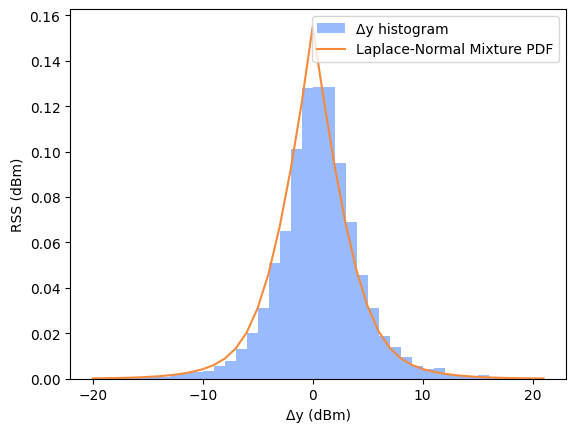

In [44]:
learn_laplace_norm_mix(diffs_2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 195 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.155,0.025,3.106,3.201,0.000,0.0,3811.0,4894.0,1.0
sigma,3.447,0.040,3.369,3.520,0.001,0.0,4162.0,5336.0,1.0
w[0],0.360,0.013,0.336,0.385,0.000,0.0,4157.0,5057.0,1.0
w[1],0.640,0.013,0.615,0.664,0.000,0.0,4157.0,5057.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


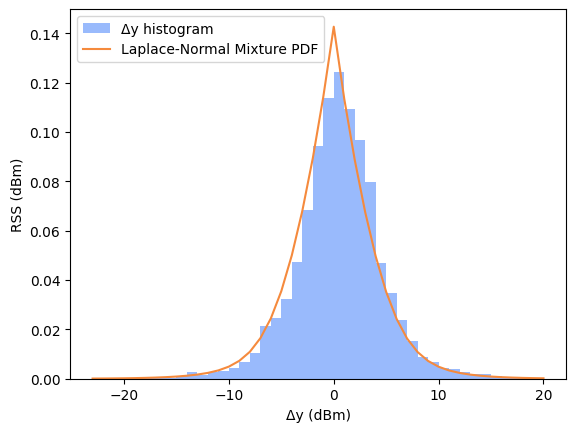

In [45]:
learn_laplace_norm_mix(diffs_5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [w, sigma, b]


Output()

Sampling 3 chains for 1_000 tune and 3_000 draw iterations (3_000 + 9_000 draws total) took 165 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,3.336,0.035,3.271,3.404,0.001,0.000,3954.0,4491.0,1.0
sigma,3.645,0.053,3.543,3.741,0.001,0.001,4280.0,4364.0,1.0
w[0],0.392,0.015,0.365,0.420,0.000,0.000,4567.0,5046.0,1.0
w[1],0.608,0.015,0.580,0.635,0.000,0.000,4567.0,5046.0,1.0


/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


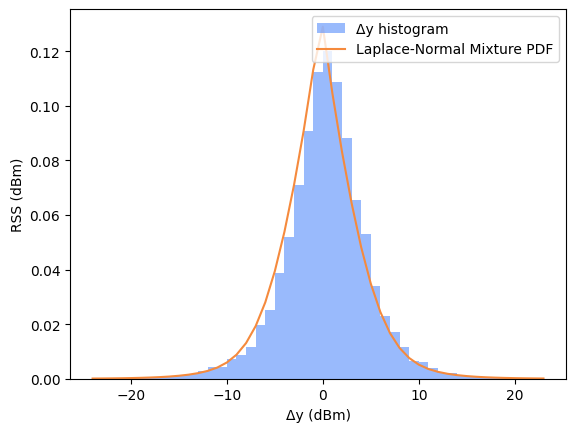

In [46]:
learn_laplace_norm_mix(diffs_10)